In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection\bank_fraud.csv')

# Basic check
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (1000000, 26)

Columns:
 ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_type']

Dtypes:
 transaction_id                  str
customer_id                     str
transaction_date                str
transaction_time                str
hour_of_day                   int64
is_weekend                    int64
is_night_transaction          int64
country                         str
city                            str
merchant_category               str
payment_method                  str
device_type                     str
customer_age                  int64
cr

In [2]:
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print("Fraud counts:")
print(fraud_counts)
print("\nFraud percentages:")
print(fraud_pct.round(2))
print(f"\nFraud rate: {fraud_pct[1]:.2f}%")
print(f"Legitimate: {fraud_pct[0]:.2f}%")
print(f"\nClass ratio (legit:fraud): {fraud_counts[0]/fraud_counts[1]:.1f}:1")

Fraud counts:
is_fraud
0    944745
1     55255
Name: count, dtype: int64

Fraud percentages:
is_fraud
0    94.47
1     5.53
Name: proportion, dtype: float64

Fraud rate: 5.53%
Legitimate: 94.47%

Class ratio (legit:fraud): 17.1:1


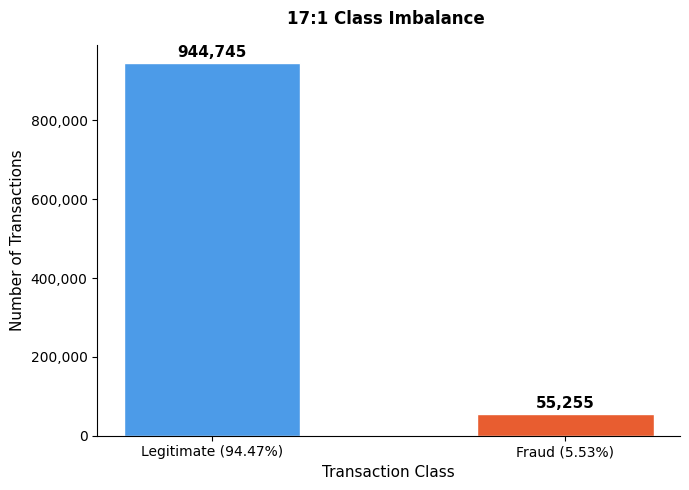

Saved.


In [3]:
# Imbalance bars

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Legitimate (94.47%)', 'Fraud (5.53%)'],
    [944745, 55255],
    color=['#4C9BE8', '#E85D30'],
    edgecolor='white',
    width=0.5
)

for bar, count in zip(bars, [944745, 55255]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8000,
            f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('17:1 Class Imbalance ',
             fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('Number of Transactions', fontsize=11)
ax.set_xlabel('Transaction Class', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection\notebook\plots\class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## 2.0 Class Imbalance — Observation

The dataset contains 944,745 legitimate transactions (94.47%) and 55,255 fraudulent 
transactions (5.53%), producing a 17:1 class ratio.

**Why this matters:**
A naive model that predicts "legitimate" on every transaction achieves 94.47% accuracy 
while catching zero fraud. Accuracy is therefore a completely meaningless metric for 
this problem and will never be reported in this notebook.

**Metrics we will use instead:** Precision, Recall, F1-Score, and AUC-ROC.

**Imbalance handling decision:**
With 55,255 fraud cases, the absolute fraud volume is sufficient for training without 
synthetic oversampling. We will use `class_weight='balanced'` in Logistic Regression 
and `scale_pos_weight=17` in XGBoost rather than SMOTE, avoiding the risk of 
synthetic samples distorting decision boundaries.

### dtype optimization


In [4]:
# Define numerical and categorical columns
num_cols = ['customer_age', 'credit_score', 'account_age_years', 'account_balance',
            'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly',
            'distance_from_home_km', 'time_since_last_txn_hrs', 'failed_attempts']

cat_cols = ['country', 'merchant_category', 'payment_method', 'device_type']

binary_cols = ['is_weekend', 'is_night_transaction', 'is_international',
               'pin_changed_recently', 'is_fraud']

print("=== VALUE RANGES — BEFORE DOWNCASTING ===\n")
for col in num_cols + binary_cols:
    print(f"{col:35s} min={df[col].min()} max={df[col].max()} dtype={df[col].dtype}")


=== VALUE RANGES — BEFORE DOWNCASTING ===

customer_age                        min=18 max=85 dtype=int64
credit_score                        min=300 max=850 dtype=int64
account_age_years                   min=0.1 max=30.0 dtype=float64
account_balance                     min=100.0 max=500000.0 dtype=float64
transaction_amount                  min=1.0 max=46129.6 dtype=float64
num_prev_transactions               min=96 max=213 dtype=int64
transaction_freq_monthly            min=2 max=44 dtype=int64
distance_from_home_km               min=0.0 max=292.1 dtype=float64
time_since_last_txn_hrs             min=0.0 max=154.2 dtype=float64
failed_attempts                     min=0 max=5 dtype=int64
is_weekend                          min=0 max=1 dtype=int64
is_night_transaction                min=0 max=1 dtype=int64
is_international                    min=0 max=1 dtype=int64
pin_changed_recently                min=0 max=1 dtype=int64
is_fraud                            min=0 max=1 dtype=int64


Casting down the dytpes helps to reduce the memeory occupied during in the RAM by the data

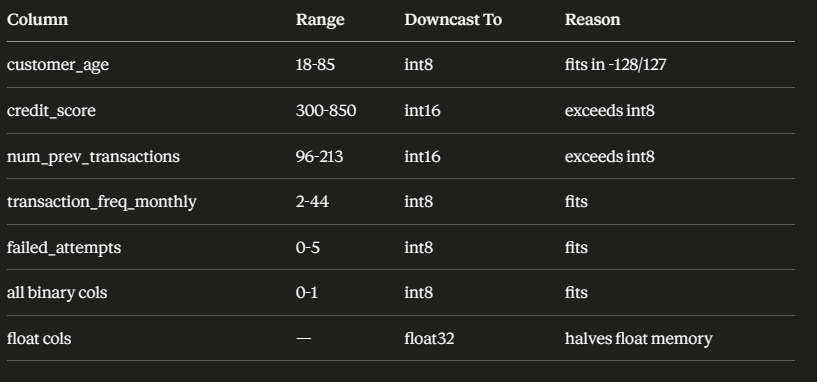

In [5]:
# Integer downcasting
df['customer_age'] = df['customer_age'].astype('int8')
df['credit_score'] = df['credit_score'].astype('int16')
df['num_prev_transactions'] = df['num_prev_transactions'].astype('int16')
df['transaction_freq_monthly'] = df['transaction_freq_monthly'].astype('int8')
df['failed_attempts'] = df['failed_attempts'].astype('int8')

for col in binary_cols:
    df[col] = df[col].astype('int8')

# Float downcasting
float_cols = ['account_age_years', 'account_balance', 'transaction_amount',
              'distance_from_home_km', 'time_since_last_txn_hrs']
for col in float_cols:
    df[col] = df[col].astype('float32')

# Verify
print("=== AFTER DOWNCASTING ===")
print(df[num_cols + binary_cols].dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

=== AFTER DOWNCASTING ===
customer_age                   int8
credit_score                  int16
account_age_years           float32
account_balance             float32
transaction_amount          float32
num_prev_transactions         int16
transaction_freq_monthly       int8
distance_from_home_km       float32
time_since_last_txn_hrs     float32
failed_attempts                int8
is_weekend                     int8
is_night_transaction           int8
is_international               int8
pin_changed_recently           int8
is_fraud                       int8
dtype: object

Memory usage: 570.3 MB


The memory usage is still 570.3 MB which is much higer, lets look for str dtypes which takes large amount of memory compared to int and float

In [6]:
mem = df.memory_usage(deep=True) / 1024**2
print(mem.sort_values(ascending=False).round(2))
print(f"\nTotal: {mem.sum():.1f} MB")

transaction_id              59.13
customer_id                 58.17
payment_method              57.18
transaction_date            56.27
merchant_category           55.88
city                        54.80
transaction_time            54.36
device_type                 52.97
country                     51.25
fraud_type                  32.13
hour_of_day                  7.63
transaction_amount           3.81
time_since_last_txn_hrs      3.81
distance_from_home_km        3.81
account_balance              3.81
account_age_years            3.81
credit_score                 1.91
num_prev_transactions        1.91
is_weekend                   0.95
is_international             0.95
is_night_transaction         0.95
customer_age                 0.95
transaction_freq_monthly     0.95
pin_changed_recently         0.95
failed_attempts              0.95
is_fraud                     0.95
Index                        0.00
dtype: float64

Total: 570.3 MB


Thinking to drop ID columns which are not useful, and checking the cardinality of other columns to make sure it is optimal.

In [7]:
# Drop only IDs — confirmed useless
df.drop(columns=['transaction_id', 'customer_id'], inplace=True)

# Check cardinality of remaining string columns before any decisions
for col in ['city', 'transaction_time', 'country', 'merchant_category', 
            'payment_method', 'device_type']:
    print(f"{col:25s} unique values: {df[col].nunique()}")

city                      unique values: 20
transaction_time          unique values: 1440
country                   unique values: 10
merchant_category         unique values: 15
payment_method            unique values: 6
device_type               unique values: 5


Dropping transaction_time — hour_of_day already captures this, and converting date to datetime, and converting categorical columns to category. 

In [8]:
# Drop transaction_time — hour_of_day already captures this
df.drop(columns=['transaction_time'], inplace=True)

# Parse date
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Convert to category
cat_convert = ['country', 'merchant_category', 'payment_method', 'device_type', 'fraud_type', 'city']
for col in cat_convert:
    df[col] = df[col].astype('category')

# Memory check
mem = df.memory_usage(deep=True) / 1024**2
print(mem.sort_values(ascending=False).round(2))
print(f"\nTotal: {mem.sum():.1f} MB")
print(f"Shape: {df.shape}")

transaction_date            7.63
hour_of_day                 7.63
transaction_amount          3.81
time_since_last_txn_hrs     3.81
distance_from_home_km       3.81
account_age_years           3.81
account_balance             3.81
credit_score                1.91
num_prev_transactions       1.91
city                        0.95
merchant_category           0.95
country                     0.95
fraud_type                  0.95
payment_method              0.95
device_type                 0.95
is_weekend                  0.95
is_international            0.95
is_night_transaction        0.95
customer_age                0.95
transaction_freq_monthly    0.95
pin_changed_recently        0.95
failed_attempts             0.95
is_fraud                    0.95
Index                       0.00
dtype: float64

Total: 51.5 MB
Shape: (1000000, 23)


**Columns dropped:**
- transaction_id, customer_id — pure identifiers, no predictive value
- transaction_time — redundant with hour_of_day which is already numeric

**Dtype optimization:**
Memory reduced from 570.3 MB to 51.5 MB (91% reduction) through:
- int64 → int8/int16 for small-range integer columns
- float64 → float32 for continuous features
- object → category for all low-cardinality string columns (≤20 unique values)

**city column:** Retained for EDA (20 unique values, low cardinality). 
Will reassess before modeling — not in the original feature list.

**Date parsing:** transaction_date converted to datetime for temporal analysis in 2.1.

String (object) vs Category in Pandas
String (object) — pandas stores every single value as a separate Python string object in memory.
So if you have 1,000,000 rows and the country column has "USA" repeated 200,000 times — pandas stores "USA" as 200,000 separate string objects in memory. Extremely wasteful.
Category — pandas stores the unique values once in a lookup table, then stores integer codes for each row.
So "USA", "UK", "Canada" etc. get stored once. Each row just stores a small integer (0, 1, 2...) pointing to that lookup table. Much cheaper.

### Univariate Analysis

In [9]:
print("=== FULL STATISTICAL SUMMARY ===")
print(df[num_cols].describe().round(2).to_string())

=== FULL STATISTICAL SUMMARY ===
       customer_age  credit_score  account_age_years  account_balance  transaction_amount  num_prev_transactions  transaction_freq_monthly  distance_from_home_km  time_since_last_txn_hrs  failed_attempts
count    1000000.00    1000000.00         1000000.00       1000000.00          1000000.00             1000000.00                1000000.00             1000000.00               1000000.00       1000000.00
mean          41.77        679.03               4.99         16594.25              204.72                 150.00                     20.00                  20.01                    12.00             0.38
std           13.42         78.83               4.93         28171.46              459.57                  12.24                      4.47                  20.01                    12.00             0.91
min           18.00        300.00               0.10           100.00                1.00                  96.00                      2.00             


**Central Tendency & Spread — Key Findings:**

**Well-behaved columns (mean ≈ median, std < mean):**
- customer_age: mean 41.77, median 42.00 — symmetric, no outlier concern
- credit_score: mean 679, median 680 — tight distribution, std of 78 on a 300-850 scale
- num_prev_transactions: mean = median = 150 — unusually uniform, likely synthetic artifact
- transaction_freq_monthly: mean = median = 20 — same concern, too perfect

**Right-skewed columns (mean >> median, std ≈ mean or std > mean):**
- account_balance: mean 2x median (16,594 vs 8,092), std larger than mean — extreme 
  right skew, max of 500,000 is 17 std away — log transform needed before modeling
- transaction_amount: mean 2.8x median (204 vs 73), max of 46,129 is 100 std away — 
  severe skew, extreme outliers confirmed
- distance_from_home_km: std equals mean (both ~20), min of 0 is valid (home transaction),
  75% of transactions within 27.7km — long tail toward 292km is where fraud likely sits
- time_since_last_txn_hrs: same pattern as distance, std equals mean (both ~12)
- account_age_years: std almost equals mean (4.93 vs 4.99), max of 30 is 5.1 std away

**Notable discrete columns:**
- failed_attempts: mean 0.38, median 0, 75th percentile 0 — most transactions have 
  zero failed attempts, non-zero values are already anomalous and likely strong fraud signal

**Modeling implications:**
- account_balance and transaction_amount will need log transformation before modeling
- distance_from_home_km and time_since_last_txn_hrs likely follow exponential distributions
- num_prev_transactions and transaction_freq_monthly look artificially uniform — 
  worth noting as synthetic data artifact, low predictive value expected

In [10]:
#Cateorical value counts and percentages

cat_cols = ['country', 'merchant_category', 'payment_method', 'device_type']

for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(2)
    summary = pd.DataFrame({'Count': freq, 'Percentage': pct})
    print(summary.to_string())


=== COUNTRY ===
            Count  Percentage
country                      
USA        299910       29.99
India      120206       12.02
UK          99677        9.97
Brazil      80351        8.04
Germany     79831        7.98
Japan       70107        7.01
France      69867        6.99
Canada      69742        6.97
Mexico      60275        6.03
Australia   50034        5.00

=== MERCHANT_CATEGORY ===
                   Count  Percentage
merchant_category                   
Entertainment      67150        6.72
Jewelry            66870        6.69
Electronics        66866        6.69
Fuel               66843        6.68
Utilities          66841        6.68
Education          66816        6.68
Clothing           66792        6.68
Travel             66692        6.67
Restaurant         66628        6.66
Healthcare         66613        6.66
Grocery            66513        6.65
ATM Withdrawal     66389        6.64
Online Shopping    66341        6.63
Gaming             66338        6.63
Cryp


**Country:**
USA accounts for 30% of all transactions — the largest single segment. Australia 
has the lowest volume at 5%, meaning country-level fraud rates for Australia will 
have higher variance and less statistical reliability.

**Merchant Category:**
All 15 categories fall between 6.63% and 6.72% — nearly perfectly uniform. 
This is a synthetic data artifact. Real-world merchant distributions are heavily 
skewed toward grocery, retail and restaurants. Fraud rates by merchant category 
will reflect engineered correlations, not organic patterns. Interpret with caution.

**Payment Method:**
Credit Card (35%) and Debit Card (30%) dominate — realistic distribution. 
Cheque (3%) has the lowest volume — fraud rate estimates for this method will 
be less statistically reliable due to small sample size.

**Device Type:**
Mobile leads at 45% — consistent with global digital payment trends. ATM, Tablet 
and POS Terminal each sit at ~10% — again suspiciously uniform, likely a synthetic 
artifact. Real device distributions skew heavily toward mobile and desktop.

**Key modeling note:**
The near-perfect uniformity in merchant_category and device_type suggests these 
features were engineered with equal representation. Fraud signal from these columns 
exists by design, not organic data generation. This does not invalidate them as 
features but means we should not over-interpret the magnitude of differences.

In [11]:
print("=== FRAUD TYPE BREAKDOWN ===\n")
fraud_only = df[df['is_fraud'] == 1]

freq = fraud_only['fraud_type'].value_counts()
pct = fraud_only['fraud_type'].value_counts(normalize=True).mul(100).round(2)
summary = pd.DataFrame({'Count': freq, 'Percentage': pct})
print(summary.to_string())
print(f"\nTotal fraud transactions: {len(fraud_only):,}")

=== FRAUD TYPE BREAKDOWN ===

                    Count  Percentage
fraud_type                           
Phishing             9252       16.74
Account Takeover     9232       16.71
Synthetic Identity   9214       16.68
Card Cloning         9200       16.65
Friendly Fraud       9187       16.63
Identity Theft       9170       16.60

Total fraud transactions: 55,255




Six fraud types are present: Phishing, Account Takeover, Synthetic Identity, 
Card Cloning, Friendly Fraud, and Identity Theft.

All six sit between 16.60% and 16.74% — perfectly uniform distribution. 
This is a synthetic data artifact. Real fraud portfolios are dominated by 
card cloning and phishing, with synthetic identity fraud being a small fraction.

**Critical modeling note:**
fraud_type is strictly excluded from all models — it is target leakage. 
The fraud type can only be determined after fraud has already been identified, 
meaning it would not exist as an input feature in a real-time scoring system.
Its presence in this dataset is for exploratory context only.

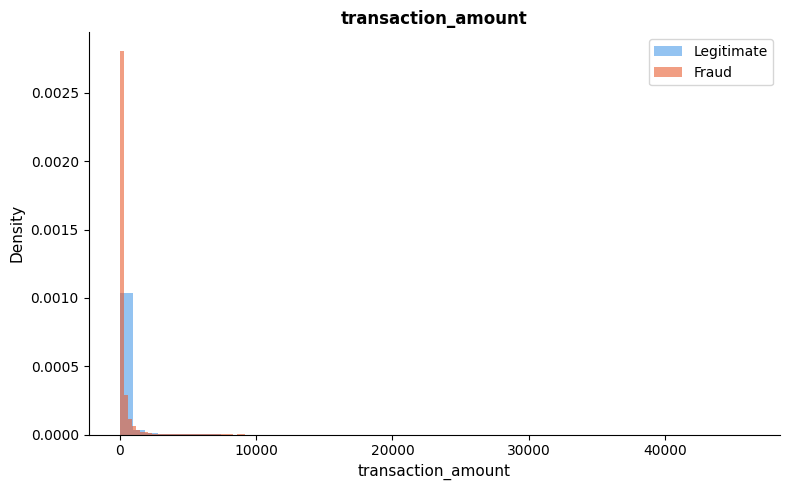

Saved: transaction_amount


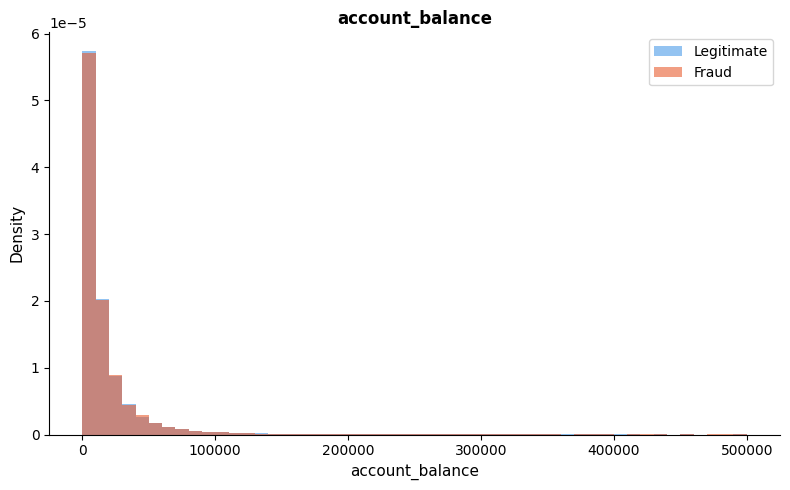

Saved: account_balance


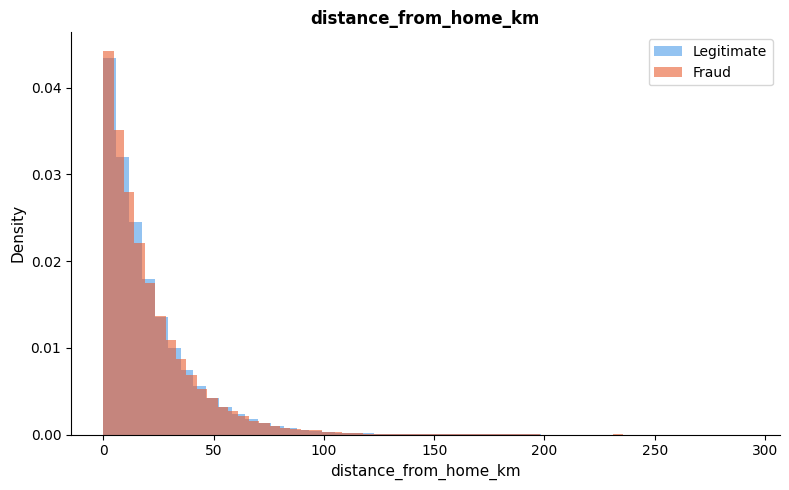

Saved: distance_from_home_km


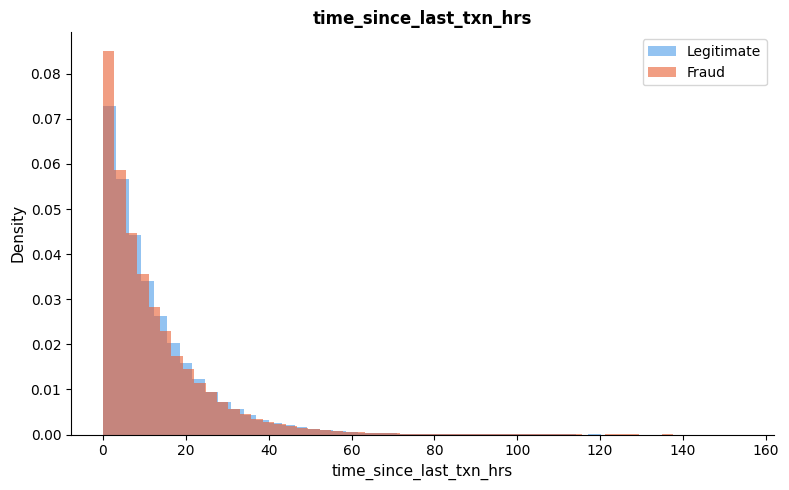

Saved: time_since_last_txn_hrs


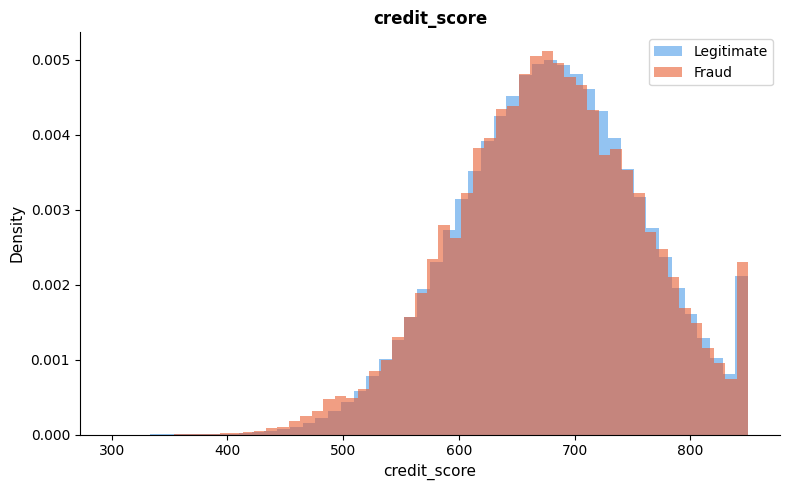

Saved: credit_score


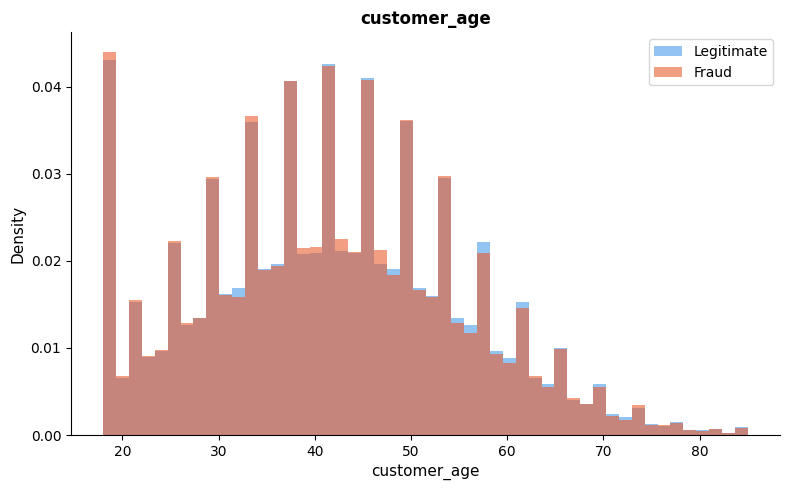

Saved: customer_age


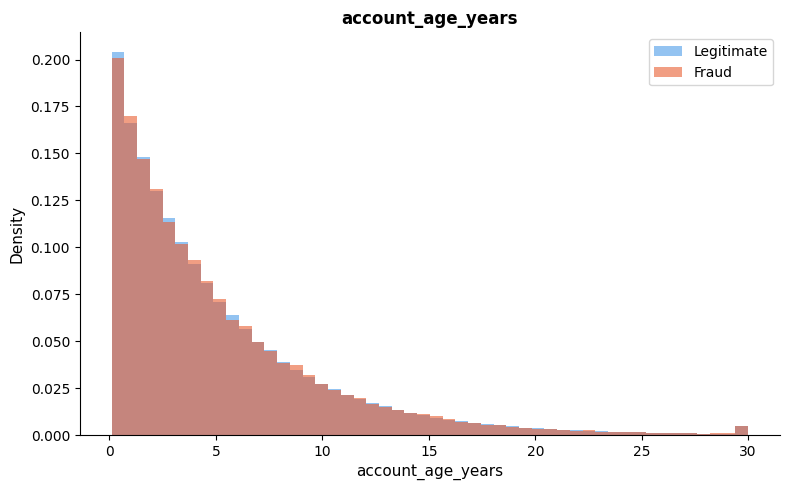

Saved: account_age_years


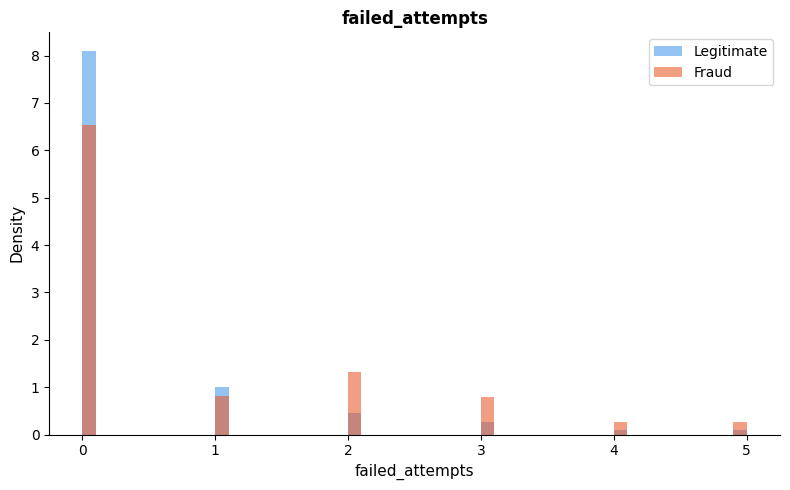

Saved: failed_attempts


In [12]:
fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]

plot_cols = ['transaction_amount', 'account_balance', 'distance_from_home_km',
             'time_since_last_txn_hrs', 'credit_score', 'customer_age',
             'account_age_years', 'failed_attempts']

for i, col in enumerate(plot_cols):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.hist(legit[col], bins=50, color='#4C9BE8', alpha=0.6, 
            label='Legitimate', density=True)
    ax.hist(fraud[col], bins=50, color='#E85D30', alpha=0.6, 
            label='Fraud', density=True)
    
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'G:/DATASCIENCE/End_to_End_Project/Banking Fraud Detection/notebook/plots/02_{i+1}_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {col}")

In [13]:
skewed_cols = ['transaction_amount', 'account_balance', 
               'distance_from_home_km', 'time_since_last_txn_hrs']

for col in skewed_cols:
    p95 = df[col].quantile(0.95)
    p99 = df[col].quantile(0.99)
    p999 = df[col].quantile(0.999)
    print(f"{col:30s} p95={p95:>10.1f}  p99={p99:>10.1f}  p99.9={p999:>10.1f}  max={df[col].max():>10.1f}")

transaction_amount             p95=     825.1  p99=    2093.0  p99.9=    5224.9  max=   46129.6
account_balance                p95=   58497.2  p99=  132636.5  p99.9=  330472.1  max=  500000.0
distance_from_home_km          p95=      59.9  p99=      92.1  p99.9=     138.7  max=     292.1
time_since_last_txn_hrs        p95=      35.9  p99=      55.3  p99.9=      83.2  max=     154.2


1. Why didn't we clip account_balance?
You're right to challenge this. The 3.8x ratio alone doesn't tell the full story. Look at the actual scale:

account_balance p99 = 132,636 and max = 500,000
transaction_amount p99 = 2,093 and max = 46,129

The issue isn't just the ratio — it's the absolute range. account_balance spans from 100 to 500,000 — that's a 5,000x range. Clipping at p99 still leaves you with a 0 to 132,636 range which is still heavily compressed visually.
Log scale handles a 5,000x range cleanly. Clipping doesn't. That's why log was the right call for account_balance, not clipping.
For distance (0 to 292) and time (0 to 154) — the ranges are small enough that clipping at p99 gives a clean readable plot without needing log transformation.

2. Why p99 specifically to decide?
Honest answer — p99 is a convention, not a law. The reasoning is:

p95 is too aggressive — you're hiding 5% of real data
p99 keeps 99% of data visible — you're only trimming the extreme tail
p99.9 is usually still too compressed if the max is extreme

The real decision process is:
If max > 10x p99  → log scale (range too extreme for clipping)
If max > 3x p99   → clip at p99 or log scale, test both visually
If max < 3x p99   → clip at p99, log not needed
transaction_amount max is 22x p99 → log
account_balance range is 5000x → log
distance max is 3.2x p99 → clip works fine
time max is 2.8x p99 → clip works fine

3. Is log transform or clipping permanent?
No. This is strictly for visualization only.
Nothing we are doing to the data right now is permanent. We are not modifying df at all — we are passing transformed values directly to the histogram. Look at the code:
python# We never did this (permanent):
df['transaction_amount'] = np.log1p(df['transaction_amount'])

# We did this (temporary, visualization only):
ax.hist(np.log1p(legit[col]), bins=50 ...)
The actual decisions about transformations for modeling happen in Stage 3 — Feature Engineering. At that point we will make deliberate, permanent decisions about:

Which columns get log transformed before modeling
Which outliers get capped/winsorized
Which get left as-is because the model handles them natively (XGBoost doesn't need normalization)

Right now we are just trying to see the data clearly. Nothing is being changed in df.

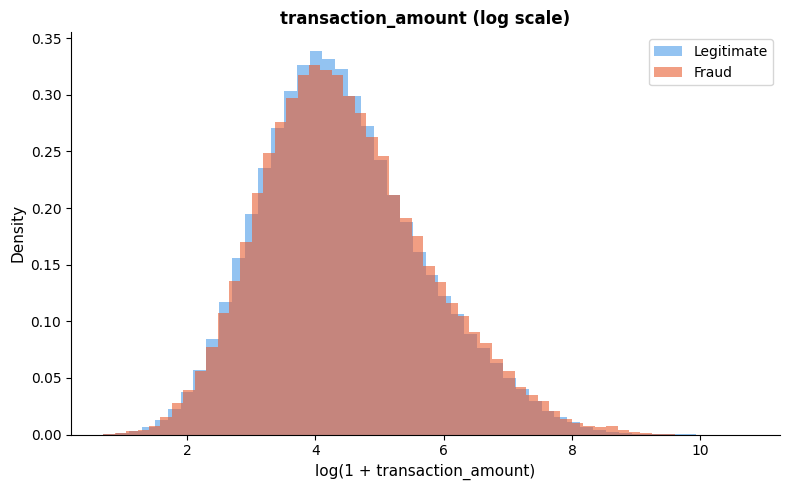

Saved: transaction_amount


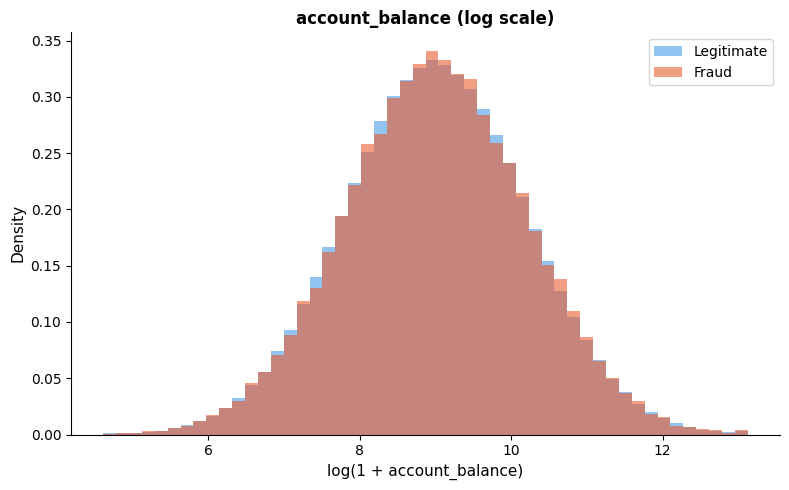

Saved: account_balance


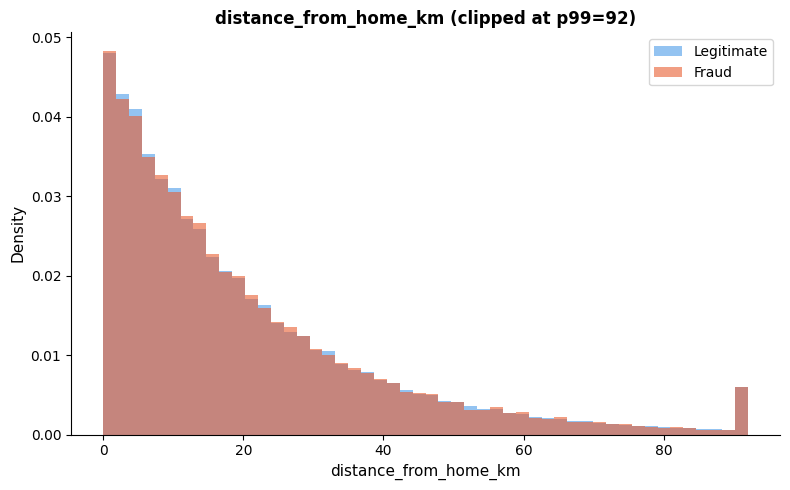

Saved: distance_from_home_km


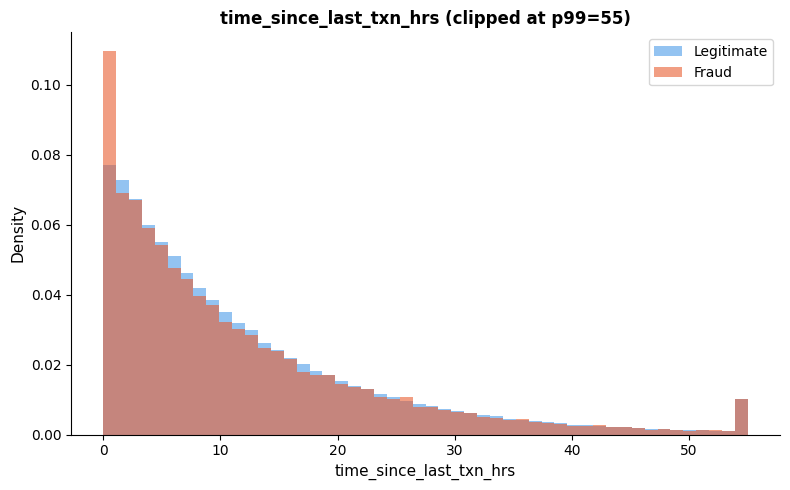

Saved: time_since_last_txn_hrs


In [14]:
import numpy as np

fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]

# Log scale columns
log_cols = ['transaction_amount', 'account_balance']
for i, col in enumerate(log_cols):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.hist(np.log1p(legit[col]), bins=50, color='#4C9BE8', 
            alpha=0.6, label='Legitimate', density=True)
    ax.hist(np.log1p(fraud[col]), bins=50, color='#E85D30', 
            alpha=0.6, label='Fraud', density=True)
    
    ax.set_title(f'{col} (log scale)', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'log(1 + {col})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'plots/02_{col}_log.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {col}")

# Clipped columns
clip_cols = {
    'distance_from_home_km': 92,
    'time_since_last_txn_hrs': 55
}

for i, (col, clip_val) in enumerate(clip_cols.items()):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.hist(legit[col].clip(upper=clip_val), bins=50, color='#4C9BE8',
            alpha=0.6, label='Legitimate', density=True)
    ax.hist(fraud[col].clip(upper=clip_val), bins=50, color='#E85D30',
            alpha=0.6, label='Fraud', density=True)
    
    ax.set_title(f'{col} (clipped at p99={clip_val})', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'plots/02_{col}_clipped.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {col}")

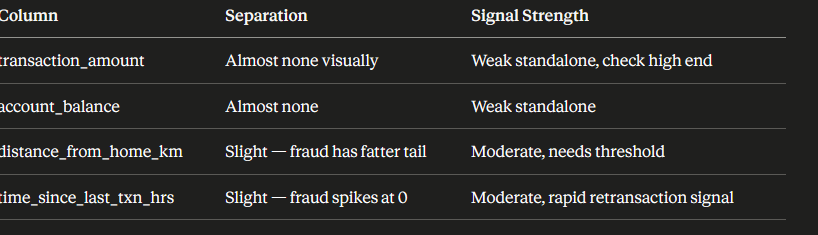

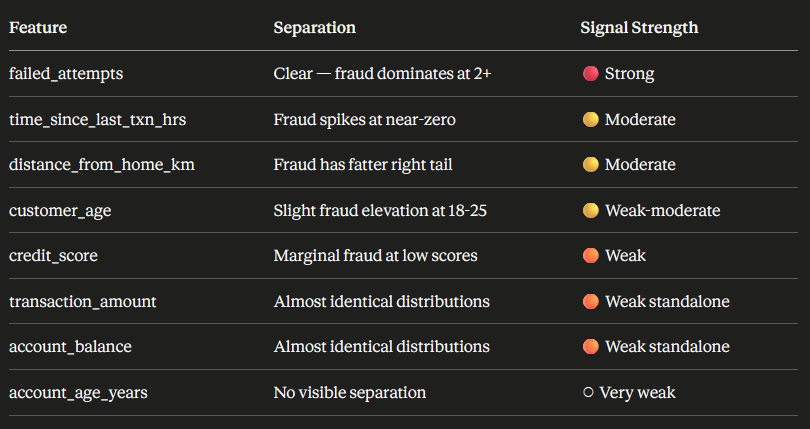

## 2.2 Distribution Analysis — Observation

**Heavily skewed columns requiring log transformation before modeling:**
transaction_amount (max is 22x p99) and account_balance (5,000x range) were 
plotted on log scale. distance_from_home_km and time_since_last_txn_hrs were 
clipped at p99 for visualization only — no permanent transformation applied.

**failed_attempts — strongest visual signal:**
At 0 failed attempts legitimate dominates. At 2+ failed attempts fraud density 
is approximately 3x legitimate density. This is the clearest visual separation 
across all features and will likely be the top predictive feature.

**time_since_last_txn_hrs — rapid retransaction signal:**
Fraud shows a noticeably higher spike at near-zero hours compared to legitimate. 
Fraudsters transact again very quickly after a previous transaction — consistent 
with account takeover behavior.

**distance_from_home_km — fat tail signal:**
Fraud has a slightly fatter right tail beyond 40km. Most transactions cluster 
near home for both classes but fraud extends further. No clean threshold visible 
— needs quantification in bivariate analysis.

**customer_age — binning artifact warning:**
Narrow spikes in the histogram are binning artifacts from discrete integer ages. 
Real pattern shows slight fraud elevation at 18-25, converging with legitimate 
from 30 onwards. Weak standalone signal.

**credit_score — directionally correct, magnitude weak:**
Fraud marginally over-represented at scores below 500, legitimate dominates 
mid-to-high range. The isolated spike at exactly 850 is a synthetic data 
artifact — max value cap in the data generator.

**account_balance and transaction_amount — no visual separation:**
Both classes follow nearly identical log-normal distributions. These features 
are weak in isolation but may contribute in combination with other signals 
in the model.

**account_age_years — no separation:**
Both classes follow identical exponential decay. Newer accounts dominate for 
both fraud and legitimate — this is a synthetic data artifact, not a real signal.

**Key modeling implication:**
No single feature cleanly separates fraud from legitimate. This confirms why 
machine learning is necessary — fraud signal lives in feature combinations, 
not individual thresholds.

In [15]:
from scipy import stats

print(f"{'Column':<30} {'Skewness':>10} {'Kurtosis':>10} {'Skew Interpretation':>25}")
print("-" * 80)

for col in num_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    if abs(skew) < 0.5:
        interp = 'Roughly symmetric'
    elif abs(skew) < 1.0:
        interp = 'Moderately skewed'
    else:
        interp = 'Highly skewed'
    
    print(f"{col:<30} {skew:>10.3f} {kurt:>10.3f} {interp:>25}")

Column                           Skewness   Kurtosis       Skew Interpretation
--------------------------------------------------------------------------------
customer_age                        0.212     -0.373         Roughly symmetric
credit_score                       -0.095     -0.218         Roughly symmetric
account_age_years                   1.814      4.098             Highly skewed
account_balance                     6.419     68.164             Highly skewed
transaction_amount                 10.198    293.844             Highly skewed
num_prev_transactions               0.082      0.009         Roughly symmetric
transaction_freq_monthly            0.221      0.049         Roughly symmetric
distance_from_home_km               2.006      6.077             Highly skewed
time_since_last_txn_hrs             2.008      6.068             Highly skewed
failed_attempts                     2.873      8.563             Highly skewed


### Univariate categorical analysis 

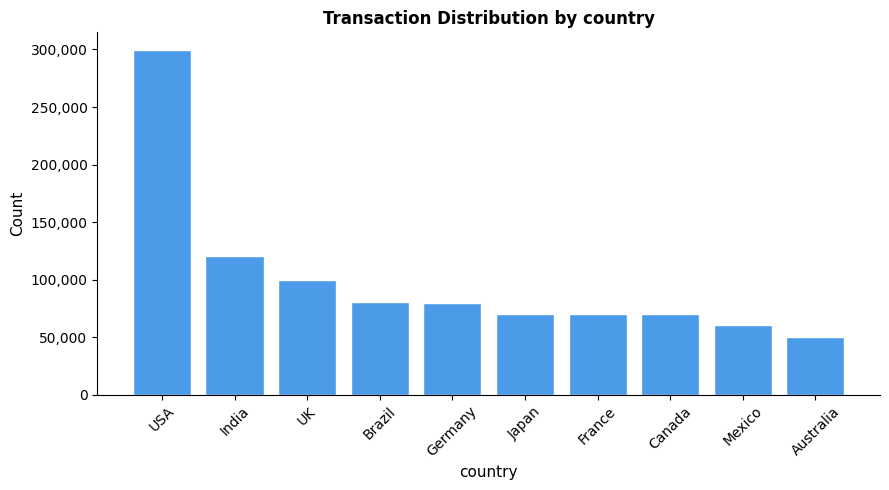

Saved: country


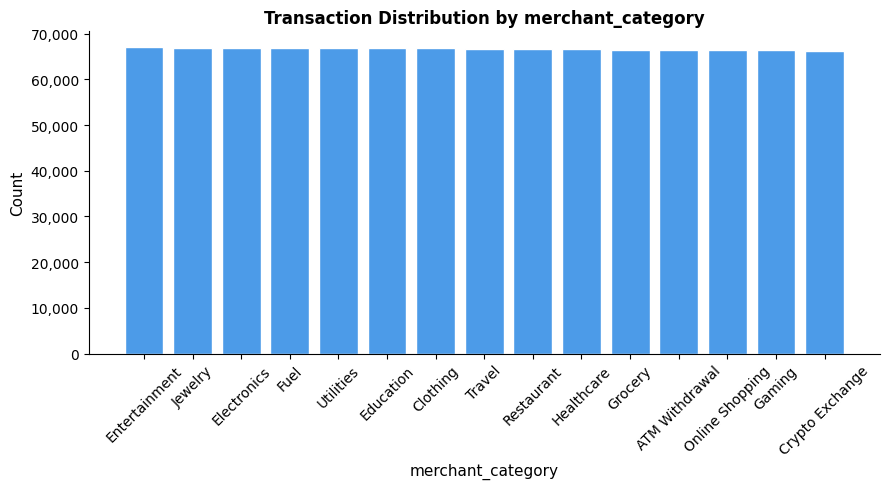

Saved: merchant_category


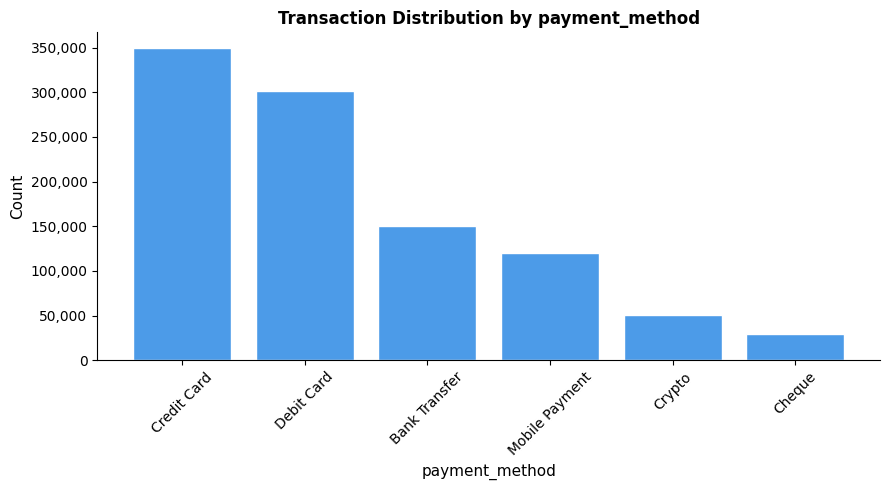

Saved: payment_method


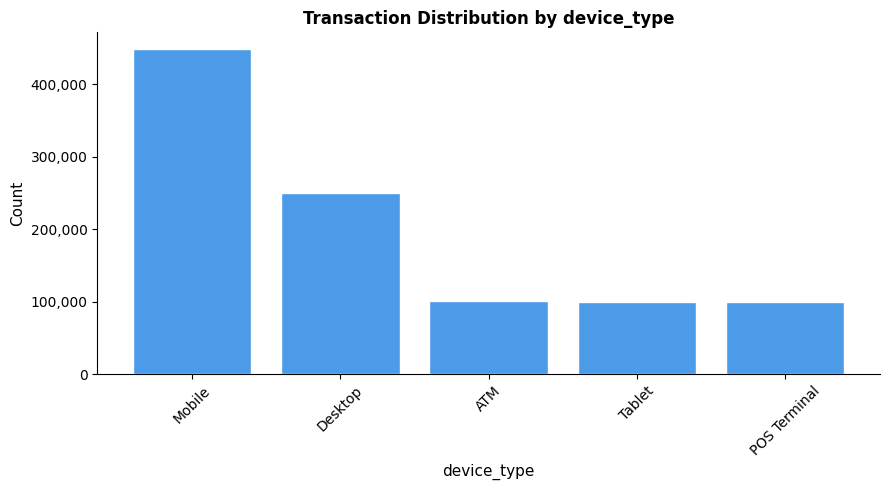

Saved: device_type


In [16]:
cat_cols = ['country', 'merchant_category', 'payment_method', 'device_type']

for col in cat_cols:
    fig, ax = plt.subplots(figsize=(9, 5))
    
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='#4C9BE8', edgecolor='white')
    
    ax.set_title(f'Transaction Distribution by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'plots/01_{col}_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {col}")

### 2.1 Univariate Analysis — Categorical Bar Charts Observation

**country:**
USA accounts for ~300K transactions — nearly 3x the second largest country (India 
at ~120K). Australia has the lowest volume at ~50K. Fraud rate estimates for 
low-volume countries will have higher statistical variance and should be 
interpreted with caution.

**merchant_category:**
All 15 categories sit at ~66-67K transactions each — perfectly flat distribution. 
This is a clear synthetic data artifact. Real merchant distributions are heavily 
skewed toward grocery and retail. Fraud signals by merchant category reflect 
engineered correlations, not organic real-world patterns.

**payment_method:**
Realistic distribution — Credit Card (350K) and Debit Card (300K) dominate. 
Crypto (50K) and Cheque (30K) have low volume, meaning their fraud rate estimates 
will be less reliable. Worth flagging in bivariate analysis.

**device_type:**
Mobile dominates at ~450K — consistent with global digital payment trends. 
ATM, Tablet and POS Terminal each sit at exactly ~100K — suspiciously uniform, 
another synthetic artifact. Real device distributions would show much more 
variation across these categories.

### Skewness and Kurtosis

In [17]:
print(f"{'Column':<30} {'Skewness':>10} {'Kurtosis':>10} {'Interpretation'}")
print("-" * 75)

for col in num_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    if abs(skew) < 0.5:
        interp = 'Roughly symmetric'
    elif abs(skew) < 1.0:
        interp = 'Moderately skewed'
    else:
        interp = 'Highly skewed'
    
    print(f"{col:<30} {skew:>10.3f} {kurt:>10.3f}   {interp}")

Column                           Skewness   Kurtosis Interpretation
---------------------------------------------------------------------------
customer_age                        0.212     -0.373   Roughly symmetric
credit_score                       -0.095     -0.218   Roughly symmetric
account_age_years                   1.814      4.098   Highly skewed
account_balance                     6.419     68.164   Highly skewed
transaction_amount                 10.198    293.844   Highly skewed
num_prev_transactions               0.082      0.009   Roughly symmetric
transaction_freq_monthly            0.221      0.049   Roughly symmetric
distance_from_home_km               2.006      6.077   Highly skewed
time_since_last_txn_hrs             2.008      6.068   Highly skewed
failed_attempts                     2.873      8.563   Highly skewed


Kurtosis intuition

Kurtosis = 0 (normal)
The "baseline." Extremes exist but at a predictable, expected rate. Think of human height — tall and short people exist but 7-foot giants are very rare and follow a predictable pattern.
Kurtosis negative
Even fewer extremes than normal. Values stay closer to the center. Like customer_age in your data — nobody is 150 years old, nobody is -10. Hard boundaries exist, extremes are impossible.
Kurtosis positive
More extremes than normal baseline. The higher the number, the more savage the outliers. Like transaction_amount — most transactions are $50-$200 but then $46,000 exists, which is so far from normal it pushes kurtosis to 293.

## 2.2 Skewness & Kurtosis — Observation

**Clean columns (skew < 0.5, kurtosis near zero or negative):**
customer_age (skew=0.21, kurt=-0.37) and credit_score (skew=-0.10, kurt=-0.22) 
are the cleanest columns — symmetric distributions with light tails, no extreme 
outliers, no transformation needed.

num_prev_transactions (skew=0.08, kurt=0.01) and transaction_freq_monthly 
(skew=0.22, kurt=0.05) show near-perfect normality — too perfect. This confirms 
synthetic generation artifact. Low predictive value expected in modeling.

**Exponential columns (skew~2.0, kurt~6.0):**
distance_from_home_km and time_since_last_txn_hrs have almost identical skewness 
and kurtosis — both follow exponential distributions. Most values cluster near 
zero, frequency drops rapidly. The heavy tails are where fraud signal lives.

**Severe outlier columns:**
account_age_years (skew=1.81, kurt=4.10) — right skewed, log transform likely.
account_balance (skew=6.42, kurt=68.16) — extreme outliers, log transform mandatory.
transaction_amount (skew=10.20, kurt=293.84) — most extreme column in the dataset.
Kurtosis of 293 confirms catastrophic right tail. Log transform mandatory.

**Special case — failed_attempts (skew=2.87, kurt=8.56):**
High skew and kurtosis but this is intentional — 75%+ of values are zero, 
non-zero values are genuine statistical extremes. This is the signal, not a 
problem. Keep as discrete count variable, no transformation.

**Stage 3 transformation decisions locked in:**
Log transform: transaction_amount, account_balance, account_age_years,
distance_from_home_km, time_since_last_txn_hrs.
No transform: customer_age, credit_score, num_prev_transactions,
transaction_freq_monthly, failed_attempts.

In [18]:
from scipy import stats

print(f"{'Column':<30} {'KS Stat':>10} {'KS p-value':>12} {'DA Stat':>10} {'DA p-value':>12} {'Normal?'}")
print("-" * 90)

for col in num_cols:
    # Standardize for KS test
    data = df[col].dropna()
    data_std = (data - data.mean()) / data.std()
    
    ks_stat, ks_p = stats.kstest(data_std, 'norm')
    da_stat, da_p = stats.normaltest(data)
    
    # Judge on KS stat magnitude not p-value
    normal = "Yes" if ks_stat < 0.05 else "No"
    
    print(f"{col:<30} {ks_stat:>10.4f} {ks_p:>12.4f} {da_stat:>10.2f} {da_p:>12.4f}  {normal}")

Column                            KS Stat   KS p-value    DA Stat   DA p-value Normal?
------------------------------------------------------------------------------------------
customer_age                       0.0383       0.0000   16282.82       0.0000  Yes
credit_score                       0.0150       0.0000    4024.73       0.0000  Yes
account_age_years                  0.1605       0.0000  357003.25       0.0000  No
account_balance                    0.2793       0.0000 1207004.38       0.0000  No
transaction_amount                 0.3292       0.0000 1621575.25       0.0000  No
num_prev_transactions              0.0218       0.0000    1128.60       0.0000  Yes
transaction_freq_monthly           0.0589       0.0000    8058.16       0.0000  No
distance_from_home_km              0.1587       0.0000  422837.31       0.0000  No
time_since_last_txn_hrs            0.1586       0.0000  423041.28       0.0000  No
failed_attempts                    0.4612       0.0000  589901.63       

## 2.2 Normality Tests — Observation

**Tests used:** D'Agostino-Pearson and Kolmogorov-Smirnov.
**Shapiro-Wilk skipped** — not designed for n > 5,000, meaningless at 1M rows.

**Critical note on p-values:**
Every column returned p=0.0000 including customer_age which is practically 
normal. This is expected at 1M rows — these tests detect any deviation from 
perfect normality no matter how trivial. P-values are completely ignored. 
KS statistic magnitude is the only meaningful interpretive measure here.

**Why we ran normality tests when skewness and kurtosis already exist:**
Skewness and kurtosis values alone are sufficient for transformation decisions.
Normality tests were run for three additional reasons:
1. Portfolio completeness — professional EDA notebooks are expected to show 
   formal normality testing. Skipping it looks like an oversight.
2. KS stat gives one consolidated number — easier to communicate overall 
   deviation from normality than explaining skewness and kurtosis separately 
   to a non-technical audience.
3. Cross-validation — when skewness, kurtosis, KS and DA all agree, the 
   conclusion is bulletproof. Agreement across all four measures gives 
   full confidence in transformation decisions.
For XGBoost specifically normality tests are almost irrelevant — XGBoost 
does not assume normality and handles non-normal features natively via 
threshold splits. Normality matters more for Logistic Regression and for 
validating assumptions before parametric tests in bivariate analysis.

**Why run both DA and KS instead of just KS:**
KS tells you IF a distribution deviates from normal and by how much.
DA tells you WHY — but DA alone does not identify the driver. You must 
cross-check DA with actual skewness and kurtosis values to determine 
whether skewness or kurtosis is dominant. DA just flags that something 
is wrong — skewness and kurtosis values tell you exactly what.

**How to identify the driver from DA + skewness + kurtosis together:**
- High DA + high skewness + high kurtosis → both driving, log transform
- High DA + high skewness + low kurtosis → skewness dominant, log transform  
- High DA + low skewness + high kurtosis → kurtosis dominant, winsorization
- Low KS + any DA → sample size inflation artifact, no transform needed

**Why log transform vs winsorization:**
- Log transform → use when skewness is the dominant driver. Log specifically 
  compresses the right tail, converting multiplicative gaps into additive ones.
  Also reduces kurtosis as a side effect.
- Winsorization (capping at p99) → use when kurtosis is the dominant driver 
  with low skewness. Distribution is roughly symmetric but has extreme outliers 
  on the tails. Winsorization caps those specific extremes without changing 
  the overall distribution shape.
- In this dataset skewness is always the dominant driver across all flagged 
  columns — log transform is consistently the correct choice. Winsorization 
  does not apply here.

**Results by column:**

Practically normal (KS < 0.05) — no transformation needed:
- credit_score (KS=0.015, DA=4,024, skew=-0.10, kurt=-0.22)
  Most normal column. Low DA confirms both components minimal.
- num_prev_transactions (KS=0.022, DA=1,128, skew=0.08, kurt=0.01)
  Lowest DA in dataset. Confirms synthetic uniform generation.
- customer_age (KS=0.038, DA=16,282, skew=0.21, kurt=-0.37)
  DA inflated by integer binning artifact at 1M rows. KS confirms 
  practically normal. Negative kurtosis means no extreme outliers.

Moderate deviation (KS 0.05–0.15):
- transaction_freq_monthly (KS=0.059, DA=8,058, skew=0.22, kurt=0.05)
  Borderline. Skewness and kurtosis both near zero — DA inflation from 
  sample size. No transformation needed.
- distance_from_home_km (KS=0.159, DA=422,837, skew=2.01, kurt=6.08)
  Both skewness and kurtosis moderate. Exponential shape confirmed.
  Log transform for Logistic Regression, leave raw for XGBoost.
- time_since_last_txn_hrs (KS=0.159, DA=423,041, skew=2.01, kurt=6.07)
  Near-identical to distance in every single measure — same exponential 
  pattern, same treatment decision.
- account_age_years (KS=0.161, DA=357,003, skew=1.81, kurt=4.10)
  Skewness dominant driver. Lower kurtosis than distance confirms 
  lighter tail. Log transform.

Significantly non-normal (KS > 0.15):
- account_balance (KS=0.279, DA=1,207,004, skew=6.42, kurt=68.16)
  DA crosses 1M — both skewness and kurtosis catastrophic simultaneously.
  Skewness dominant. Log transform mandatory.
- transaction_amount (KS=0.329, DA=1,621,575, skew=10.20, kurt=293.84)
  Most extreme continuous column. Every single measure worst in dataset.
  Log transform mandatory, no other option.
- failed_attempts (KS=0.461, DA=589,901, skew=2.87, kurt=8.56)
  Highest KS stat but completely expected — discrete count variable with 
  75% zeros. High stats are meaningless here. No transformation.

**Final transformation decisions:**
Log transform mandatory   → transaction_amount, account_balance
Log transform recommended → account_age_years
Model dependent           → distance_from_home_km, time_since_last_txn_hrs
                            (log for Logistic Regression, raw for XGBoost)
No transformation         → customer_age, credit_score, failed_attempts,
                            num_prev_transactions, transaction_freq_monthly

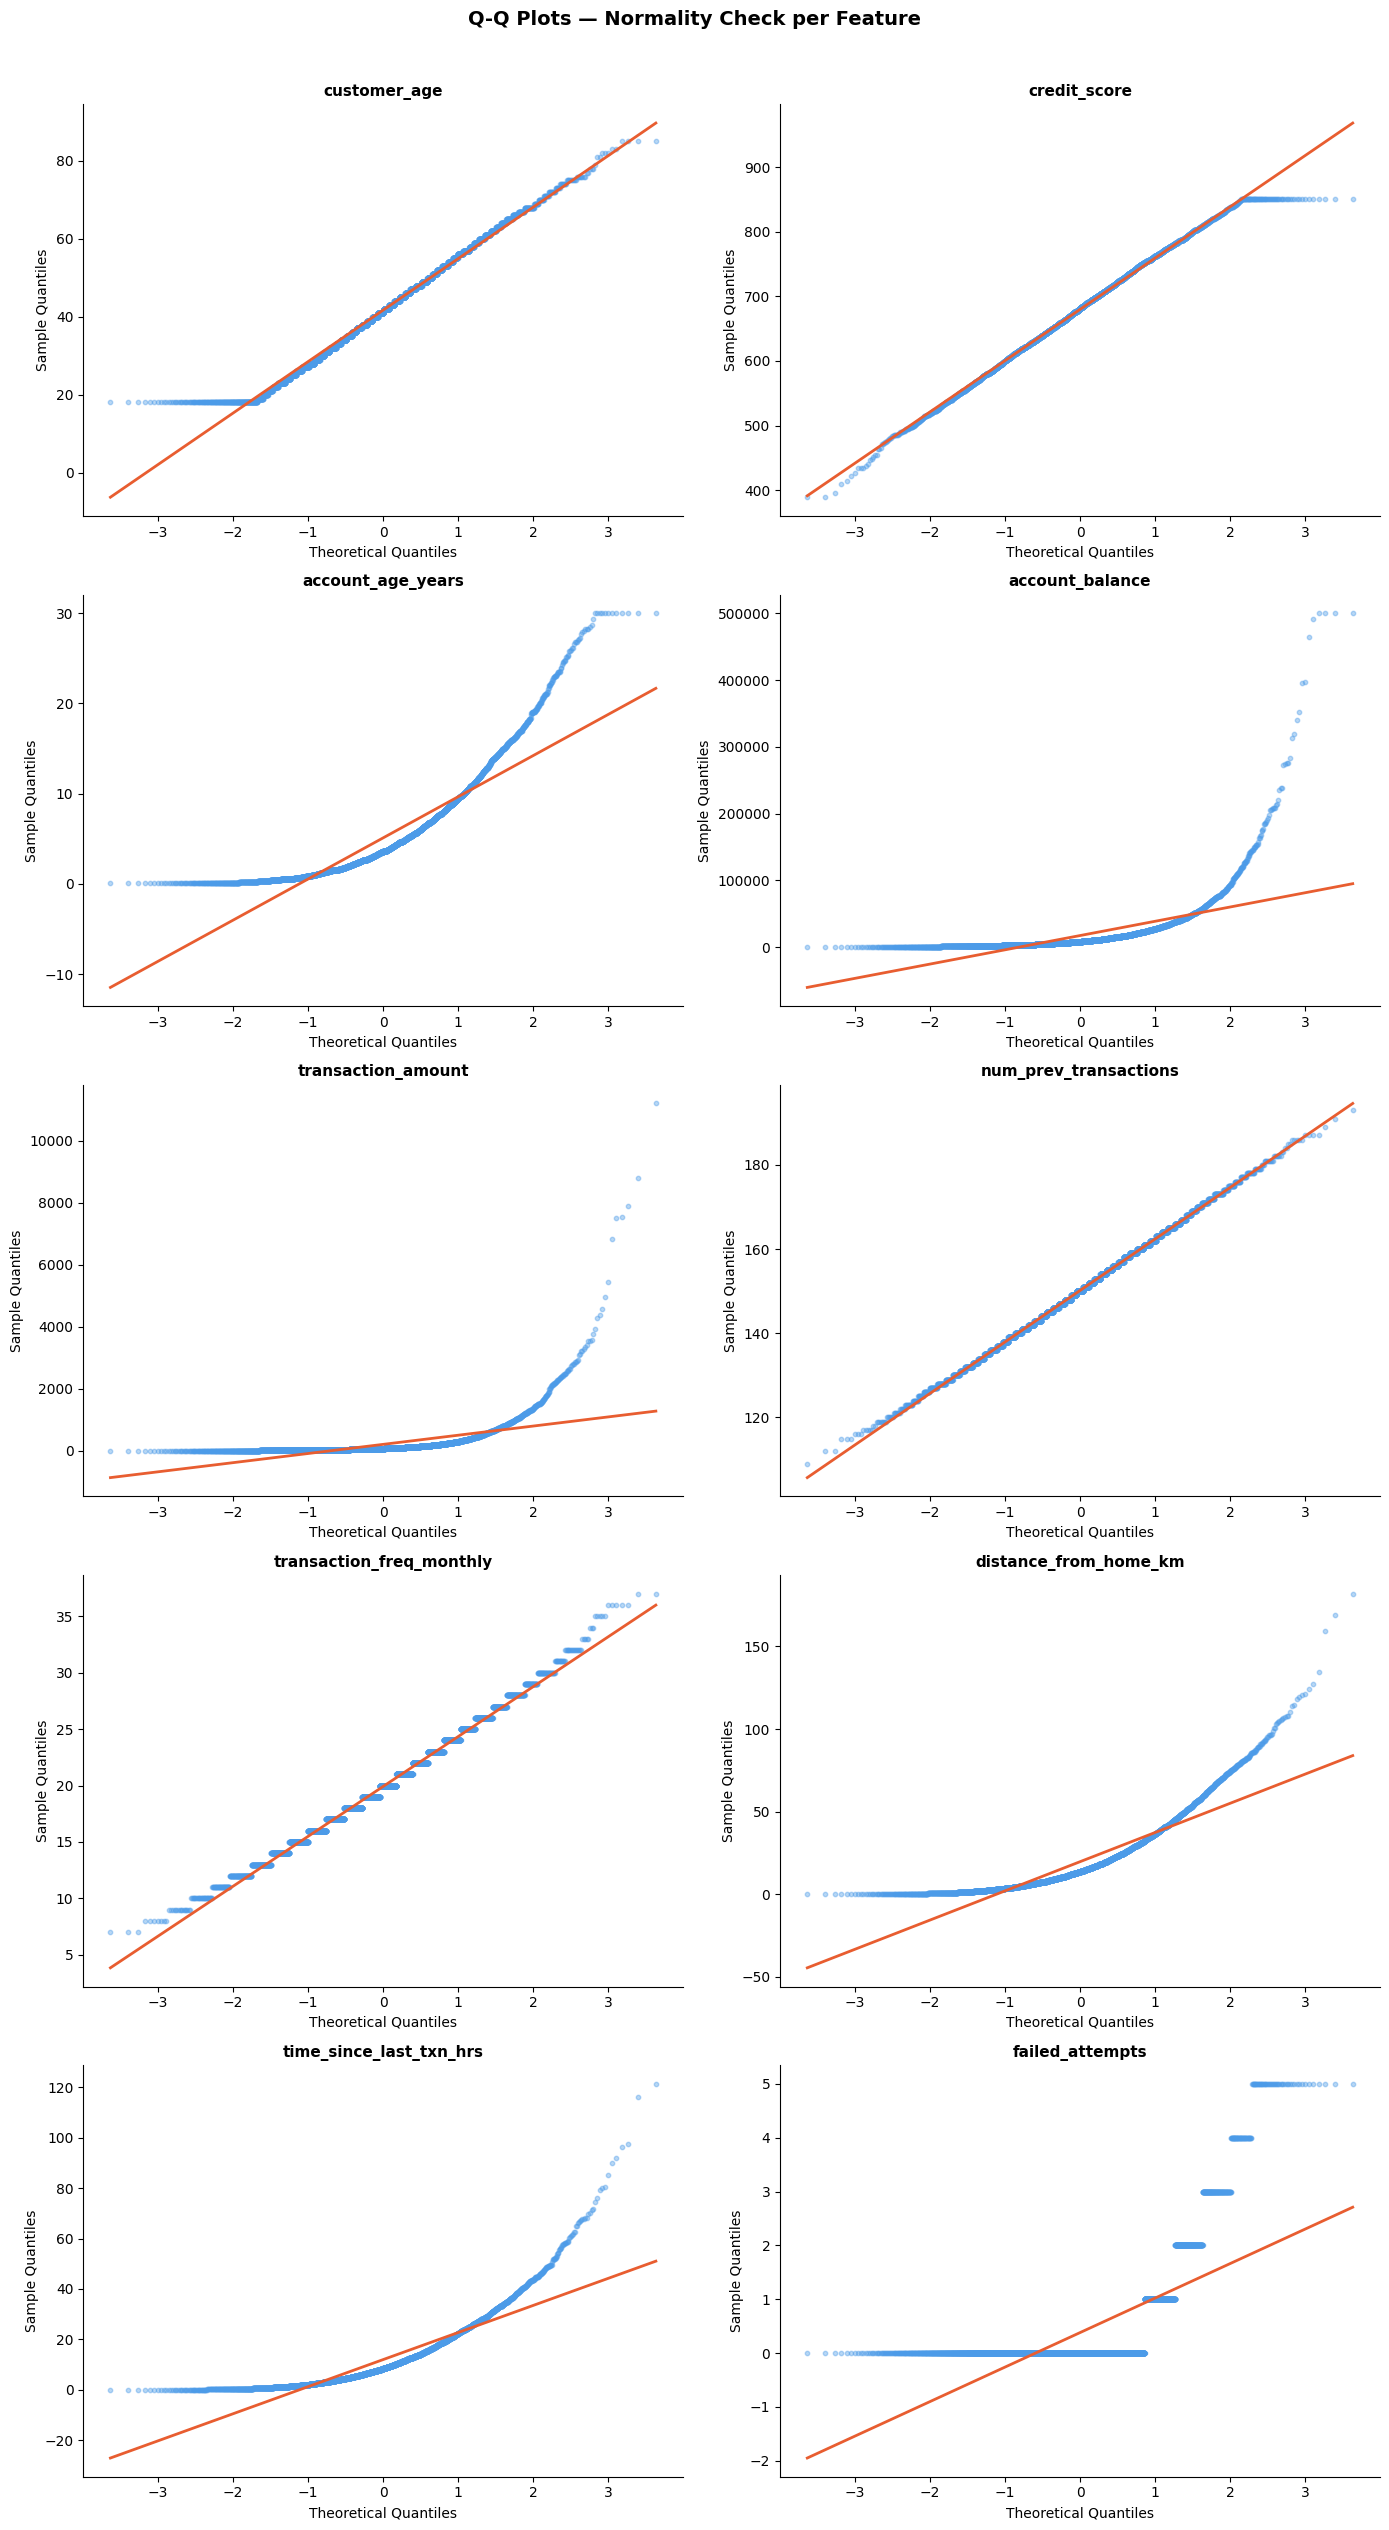

Saved.


In [19]:
from scipy import stats

fig, axes = plt.subplots(5, 2, figsize=(14, 25))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # Sample 5000 rows — QQ plot on 1M is slow and unreadable
    sample = df[col].dropna().sample(5000, random_state=42)
    
    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
    
    ax.scatter(osm, osr, color='#4C9BE8', alpha=0.4, s=10, label='Data')
    ax.plot(osm, slope * np.array(osm) + intercept, 
            color='#E85D30', linewidth=2, label='Normal line')
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=10)
    ax.set_ylabel('Sample Quantiles', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Q-Q Plots — Normality Check per Feature', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/03_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

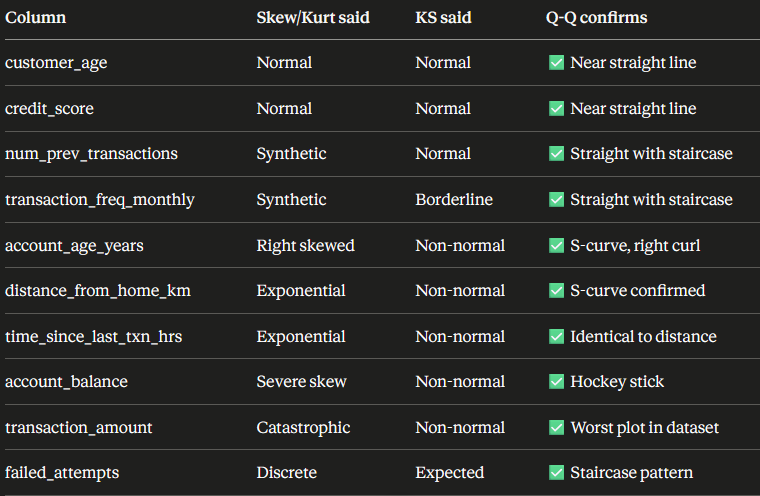

## 2.2 Q-Q Plots — Observation

Q-Q plots compare data quantiles against a theoretical normal distribution.
Points on the red line = normal. Curves away from the line = deviation.
All plots based on a stratified 5,000 row sample — 1M raw points would be
unreadable and slow.

**Near straight line (practically normal):**
- customer_age — hugs line through middle, minor deviations at age 18 
  floor and age 85 cap. Hard boundaries create slight steps, not real 
  deviation. Normal confirmed.
- credit_score — most normal plot in dataset. Flat shelf at 850 is the 
  synthetic data cap artifact, not a distribution problem.
- num_prev_transactions and transaction_freq_monthly — straight lines with 
  minor staircase stepping from discrete integer values. Synthetic uniform 
  generation visible in Q-Q plot shape.

**S-curve pattern (exponential distribution):**
- distance_from_home_km — left floor at zero, moderate right curl. 
  Exponential shape confirmed visually.
- time_since_last_txn_hrs — near-identical to distance in every measure 
  including Q-Q shape. Both follow exponential distribution confirmed.
- account_age_years — stronger S-curve than distance/time. Sharp upward 
  curl at right end confirms heavy right tail.

**Hockey stick / extreme right curl (log transform mandatory):**
- account_balance — points flat near zero across entire left half then 
  near-vertical explosion on the right. 500,000 balance accounts are 
  catastrophically far from theoretical normal placement.
- transaction_amount — worst Q-Q plot in dataset. Almost completely flat 
  then near-vertical. Skewness of 10.20 and kurtosis of 293.84 are 
  directly visible in this plot shape.

**Staircase pattern (discrete variable — expected):**
- failed_attempts — horizontal steps from only 6 possible values (0-5). 
  This is the expected Q-Q signature of a discrete variable. Red line 
  is meaningless here. No transformation needed.

**Key finding:**
Every Q-Q plot confirmed what skewness, kurtosis and KS tests already 
told us — no surprises. This is expected in rigorous EDA. All four 
measures (skewness, kurtosis, KS stat, Q-Q plot) agree on every single 
column, giving full confidence in transformation decisions for Stage 3.

In [20]:


Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3.0 * IQR
upper = Q3 + 3.0 * IQR

outlier_mask = (df[num_cols] < lower) | (df[num_cols] > upper)

iqr_summary = pd.DataFrame({
    'Q1':            Q1,
    'Q3':            Q3,
    'IQR':           IQR,
    'Lower Fence':   lower,
    'Upper Fence':   upper,
    'Outlier Count': outlier_mask.sum(),
    'Outlier %':     (outlier_mask.sum() / len(df) * 100).round(2)
})

print(iqr_summary[['Lower Fence', 'Upper Fence', 'Outlier Count', 'Outlier %']].to_string())

                           Lower Fence   Upper Fence  Outlier Count  Outlier %
customer_age                -25.000000    108.000000              0       0.00
credit_score                298.000000   1061.000000              0       0.00
account_age_years           -15.100000     23.400000           9198       0.92
account_balance          -40239.003174  62073.045105          44999       4.50
transaction_amount         -410.749985    625.599983          71868       7.19
num_prev_transactions        94.000000    206.000000              5       0.00
transaction_freq_monthly     -1.000000     41.000000             12       0.00
distance_from_home_km       -59.900002     93.400002           9343       0.93
time_since_last_txn_hrs     -36.089997     56.169997           9275       0.93
failed_attempts               0.000000      0.000000         199963      20.00


## 2.3.1 — IQR Outlier Detection

**Method:** IQR fences at Q1 ± 3.0×IQR (Tukey extreme — more conservative than standard 1.5×).
3.0 used instead of 1.5 because at 1M rows with right-skewed distributions, 1.5×IQR tags
10–20% of legitimate transactions as outliers — that's noise, not analysis.

**Findings:**

- `customer_age`, `credit_score`: zero outliers — clean normally distributed columns confirmed.
- `num_prev_transactions`, `transaction_freq_monthly`: effectively zero — synthetic uniform
  generation artifact, no real extremes.
- `transaction_amount` (7.19%) and `account_balance` (4.50%): IQR is inappropriate here.
  Upper fences of $625 and $62,073 flag legitimate high-value transactions. These are not errors
  — they are real values in a right-skewed financial distribution.
- `account_age_years`, `distance_from_home_km`, `time_since_last_txn_hrs`: ~1% each — genuine
  tail values representing old accounts, far-from-home transactions, and long gaps. Plausible,
  not errors.
- `failed_attempts`: IQR = 0 (Q1=Q3=0 on a zero-inflated discrete column). The 20% "outlier"
  figure is a methodology artifact — meaningless. Any value above 0 is flagged, which defeats
  the purpose entirely.

**Decision:** No values dropped. IQR confirmed no data entry errors. All flagged values are
legitimate extreme observations in a right-skewed financial dataset. Outlier treatment deferred
to modeling stage via robust transforms (log) already decided in 2.2.

In [21]:
# ── 2.3.2  Z-score Outlier Detection ─────────────────────────────────────

from scipy import stats

z_scores = np.abs(stats.zscore(df[num_cols].astype(float)))

z_outlier_mask = z_scores > 3.0

z_summary = pd.DataFrame({
    'Max Z-Score':     z_scores.max(axis=0).round(2),
    'Outlier Count':   z_outlier_mask.sum(axis=0),
    'Outlier %':       (z_outlier_mask.sum(axis=0) / len(df) * 100).round(2)
}, index=num_cols)

print(z_summary.to_string())

                          Max Z-Score  Outlier Count  Outlier %
customer_age                     3.22           1637       0.16
credit_score                     4.81           1526       0.15
account_age_years                5.08          19382       1.94
account_balance                 17.16          17811       1.78
transaction_amount              99.93          17388       1.74
num_prev_transactions            5.15           2874       0.29
transaction_freq_monthly         5.36           2910       0.29
distance_from_home_km           13.60          18228       1.82
time_since_last_txn_hrs         11.85          18235       1.82
failed_attempts                  5.05          20067       2.01


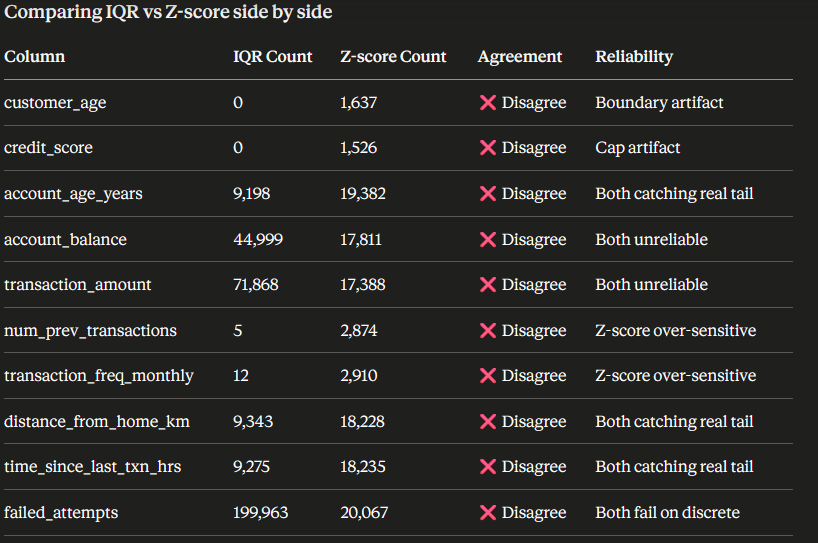

## 2.3.2 — Z-score Outlier Detection

**Method:** |Z| > 3.0 threshold (flags values beyond ±3 standard deviations from the mean).

**Key findings:**

- `customer_age`, `credit_score`: Small counts flagging synthetic boundary caps (age 85,
  score 850) — not errors.
- `transaction_amount` (Max Z = 99.93) and `account_balance` (Max Z = 17.16): Masking effect
  confirmed. Inflated std compresses Z-scores, making the threshold unreliable. Z-score flags
  ~17K rows vs IQR's ~45–72K on the same columns — a 3–4x disagreement.
- `num_prev_transactions`, `transaction_freq_monthly`: Z-score over-sensitive due to
  artificially tight synthetic distributions. 2,900 flagged vs near-zero from IQR.
- `failed_attempts`: Z-score flags anyone with 3+ failed attempts (2.01%). This is a business
  rule threshold, not an outlier finding. Method fails on zero-inflated discrete columns.
- IQR and Z-score disagree on every single column — a direct consequence of applying two
  univariate methods with different failure modes to skewed, discrete, and synthetic data.

**Decision:** No values dropped. Both methods confirm the absence of data entry errors.
All flagged values are legitimate extremes, synthetic artifacts, or potential fraud signals.
Isolation Forest (next) will provide multivariate outlier detection not subject to these
limitations.

In [22]:
# ── 2.3.3  Isolation Forest Outlier Detection ─────────────────────────────

from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

df['iso_anomaly'] = iso_forest.fit_predict(df[num_cols])
# fit_predict returns -1 for anomalies, 1 for normal
df['iso_score'] = iso_forest.score_samples(df[num_cols])
# score_samples: more negative = more anomalous

n_anomalies = (df['iso_anomaly'] == -1).sum()
pct_anomalies = n_anomalies / len(df) * 100

print(f"Total anomalies flagged : {n_anomalies:,}")
print(f"Anomaly rate            : {pct_anomalies:.2f}%")
print()

# How many of the flagged anomalies are actually fraud?
anomaly_fraud = df[df['iso_anomaly'] == -1]['is_fraud'].value_counts()
anomaly_fraud_pct = df[df['iso_anomaly'] == -1]['is_fraud'].mean() * 100

print("Among flagged anomalies:")
print(anomaly_fraud)
print(f"Fraud rate inside anomalies : {anomaly_fraud_pct:.2f}%")
print()

# Of all actual fraud, how much did Isolation Forest catch?
total_fraud = df['is_fraud'].sum()
caught_fraud = df[(df['iso_anomaly'] == -1) & (df['is_fraud'] == 1)].shape[0]
recall = caught_fraud / total_fraud * 100

print(f"Total fraud in dataset      : {total_fraud:,}")
print(f"Fraud caught by ISO Forest  : {caught_fraud:,}")
print(f"Fraud recall (unsupervised) : {recall:.2f}%")

Total anomalies flagged : 50,000
Anomaly rate            : 5.00%

Among flagged anomalies:
is_fraud
0    45187
1     4813
Name: count, dtype: int64
Fraud rate inside anomalies : 9.63%

Total fraud in dataset      : 55,255
Fraud caught by ISO Forest  : 4,813
Fraud recall (unsupervised) : 8.71%


## Evaluation Metrics — Precision, Recall, F1, AUC-ROC

---

### The Confusion Matrix — Four Outcomes of Every Prediction

Every prediction a classifier makes falls into one of four buckets:

|                        | Predicted Fraud | Predicted Legitimate |
|------------------------|-----------------|----------------------|
| **Actually Fraud**     | True Positive (TP) | False Negative (FN) |
| **Actually Legitimate**| False Positive (FP) | True Negative (TN) |

**True Positive (TP)** — Model said fraud, it actually was fraud. Caught it.

**True Negative (TN)** — Model said legitimate, it actually was legitimate. Correct, no action needed.

**False Positive (FP)** — Model said fraud, it was actually legitimate. A real customer's
transaction was blocked. They call the bank. Operational cost and customer trust damage.

**False Negative (FN)** — Model said legitimate, it was actually fraud. Missed it entirely.
The fraudster wins. Direct financial loss to the bank.

---

### The Fundamental Tradeoff

Every fraud model lives on a knife edge between these two errors. You cannot minimize
both simultaneously.

- Flag everything as fraud → catch every fraudster (zero FN) but block every legitimate
  customer (maximum FP)
- Flag nothing → block no one (zero FP) but catch no fraud (maximum FN)

The business question is always: **which error is more expensive?**

In banking, a missed fraud costs the bank directly — they absorb the loss. A false positive
costs customer trust and review queue resources. Different banks make different tradeoff
decisions based on their risk appetite. The model's threshold is set to reflect that decision.

---

### Precision

**Precision = TP / (TP + FP)**

"Of everything I flagged as fraud, what fraction was actually fraud?"

Measures the quality of alerts. High precision = when you raise an alarm it is usually right.
Low precision = alerts are mostly noise, review team is wasting time on legitimate transactions.

**Example:** Flag 1,000 transactions. 100 are fraud, 900 are legitimate.
Precision = 100 / 1,000 = 10% — 90% of alerts are false alarms.

---

### Recall

**Recall = TP / (TP + FN)**

"Of all the actual fraud that existed, what fraction did I catch?"

Measures coverage. High recall = catching most fraud. Low recall = fraud is slipping through.

**Example:** 55,255 fraud cases exist. Model caught 4,813.
Recall = 4,813 / 55,255 = 8.71% — 91.29% of fraud went undetected.

---

### False Positive Rate

**FPR = FP / (FP + TN)**

"Of all the legitimate transactions, what fraction did I incorrectly flag?"

The customer disruption metric. High FPR = constantly blocking legitimate customers.

**Example:** 944,745 legitimate transactions. 45,187 incorrectly flagged.
FPR = 45,187 / 944,745 = 4.78% — roughly 1 in 21 legitimate transactions blocked.

---

### F1-Score — Why Harmonic Mean, Not Arithmetic Mean

**F1 = 2 × (Precision × Recall) / (Precision + Recall)**

Precision and recall pull in opposite directions — improving one usually hurts the other.
F1 combines both into a single number using the harmonic mean.

**Why harmonic mean and not a regular average?**

Arithmetic mean treats both numbers equally regardless of imbalance. Harmonic mean is always
pulled toward the lower value — it cannot stay high if either input collapses.

| Precision | Recall | Arithmetic Mean | Harmonic Mean (F1) |
|-----------|--------|-----------------|--------------------|
| 90%       | 90%    | 90%             | 90%                |
| 90%       | 50%    | 70%             | 64%                |
| 90%       | 10%    | 50%             | 18%                |
| 99%       | 1%     | 50%             | 2%                 |

The last row is the critical case. A model that flags almost nothing achieves 99% precision
(every alert is correct) but 1% recall (missing everything). Arithmetic mean says 50% —
sounds passable. Harmonic mean says 2% — correctly exposes the model as useless.

A model can game arithmetic mean by being extremely conservative. Harmonic mean closes
that loophole. This is why F1 uses it.

---

### AUC-ROC — Threshold-Independent Performance

AUC-ROC evaluates the model across all possible thresholds simultaneously, not at a single
cutoff point.

The ROC curve plots:
- Y-axis: True Positive Rate (Recall) — fraud caught
- X-axis: False Positive Rate — legitimate transactions incorrectly blocked

At every possible threshold from 0 to 1, you get one point on this curve.
AUC is the Area Under that Curve.

| AUC Value | Interpretation |
|-----------|----------------|
| 1.0       | Perfect — catches all fraud with zero false positives at some threshold |
| 0.85+     | Strong model for fraud detection on tabular data |
| 0.70–0.85 | Decent — meaningful separation between fraud and legitimate |
| 0.50      | Random guessing — no better than a coin flip |
| < 0.50    | Worse than random — predictions are inverted |

AUC is useful because it is threshold-independent. It measures the model's fundamental
ability to rank fraud above legitimate transactions regardless of where you set the cutoff.
This makes it the primary comparison metric when evaluating multiple models.

---

### Applied to Isolation Forest Results

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Recall | 8.71% | Caught 4,813 of 55,255 frauds — missed 91.29% |
| Precision proxy | 9.63% | 1 in 10 flagged transactions is actual fraud |
| False positives | 45,187 | Legitimate transactions incorrectly flagged |
| FPR | 4.78% | 1 in 21 legitimate transactions blocked |

Recall is catastrophically low because Isolation Forest is unsupervised — it had no fraud
labels and could only find statistical anomalies in numerical features. Fraudulent transactions
in this dataset were synthetically designed to look numerically normal, making them
indistinguishable from legitimate transactions on raw feature magnitudes alone. This is
expected behavior, not a model failure. It confirms why supervised learning with behavioral
and contextual features is necessary.

---

### Metrics Used in This Project

Accuracy is **never** reported. A naive model predicting legitimate on every transaction
achieves 94.47% accuracy while catching zero fraud — accuracy is meaningless under 17:1
class imbalance.

**Metrics used: Precision, Recall, F1-Score, AUC-ROC only.**

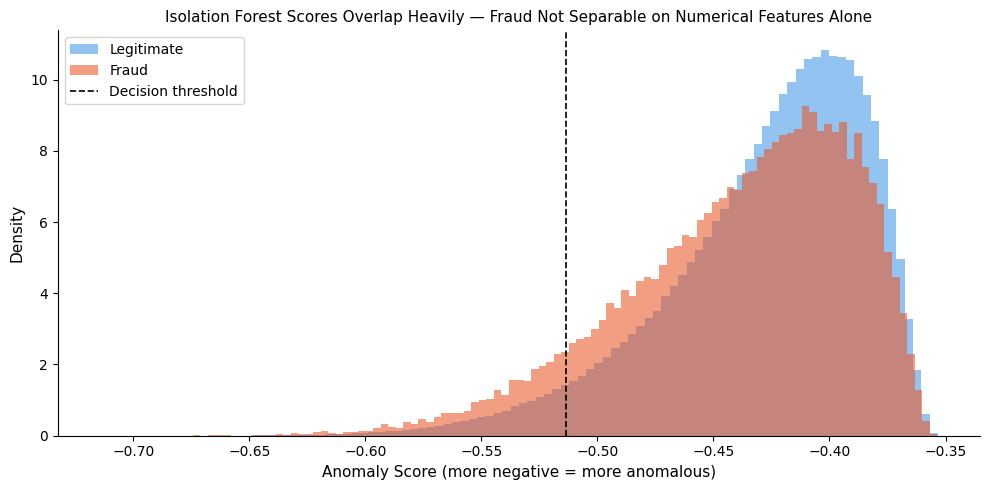


Score stats — Legitimate: mean=-0.4272, std=0.0433
Score stats — Fraud     : mean=-0.4391, std=0.0491


In [23]:
# ── Anomaly Score Distribution ─────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df[df['is_fraud'] == 0]['iso_score'], bins=100,
        alpha=0.6, color='#4C9BE8', label='Legitimate', density=True)
ax.hist(df[df['is_fraud'] == 1]['iso_score'], bins=100,
        alpha=0.6, color='#E85D30', label='Fraud', density=True)

ax.axvline(df[df['iso_anomaly'] == -1]['iso_score'].max(),
           color='black', linestyle='--', linewidth=1.2,
           label=f'Decision threshold')

ax.set_xlabel('Anomaly Score (more negative = more anomalous)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Isolation Forest Scores Overlap Heavily — Fraud Not Separable on Numerical Features Alone',
             fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/15_isolation_forest_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nScore stats — Legitimate: mean={df[df['is_fraud']==0]['iso_score'].mean():.4f}, "
      f"std={df[df['is_fraud']==0]['iso_score'].std():.4f}")
print(f"Score stats — Fraud     : mean={df[df['is_fraud']==1]['iso_score'].mean():.4f}, "
      f"std={df[df['is_fraud']==1]['iso_score'].std():.4f}")

In [24]:
df.drop(columns=['iso_anomaly', 'iso_score'], inplace=True)
print(df.shape)

(1000000, 23)


## 2.3.3 — Isolation Forest Outlier Detection

**Setup:** Trained on num_cols only (10 numerical features). Categorical columns excluded —
encoding decisions deferred to Stage 4. contamination=0.05, n_estimators=100, random_state=42.

**Results:**

| Metric | Value |
|--------|-------|
| Anomalies flagged | 50,000 (5.00%) |
| Fraud inside flagged anomalies | 4,813 (9.63% fraud rate) |
| Lift over baseline | 1.74x (baseline fraud rate 5.53%) |
| Fraud recall | 8.71% — caught 4,813 of 55,255 fraud cases |
| False positives | 45,187 legitimate transactions flagged |

**Score distribution:** Both fraud and legitimate distributions are near-identical, peaking
at approximately −0.40 with almost complete overlap. No threshold position on the score axis
cleanly separates the two classes. The decision threshold cuts through equal densities of
both classes — mechanically explaining the low precision of 9.63%.

**Root cause of low recall:** Fraudulent transactions in this dataset were synthetically
designed to blend in on raw numerical feature magnitudes. The fraud signal lives in
behavioral and contextual feature combinations — failed_attempts, is_night_transaction,
is_international, pin_changed_recently — not in numerical magnitudes alone. Isolation Forest,
operating unsupervised on numerical features only, cannot access those signals.

**This is expected and informative, not a failure.** It confirms that fraud in this dataset
is not detectable through statistical anomaly detection on numerical features alone. Supervised
models with the full feature set — including behavioral and categorical variables — are
required to achieve meaningful recall. Isolation Forest will be re-evaluated as a formal
benchmark in Stage 5 with this limitation explicitly documented.

What would a good plot look like
If the model were working well, the orange distribution would be shifted significantly left relative to blue — fraud would cluster in the highly anomalous region and legitimate would cluster in the normal region. The two peaks would be visibly separated with a clear valley between them. You'd place the threshold in that valley and get high recall with manageable false positives. That's not what we have.

**Decision:** DBSCAN and Mahalanobis Distance skipped.

**Reason:** Isolation Forest ran on the full 1,000,000 rows using all 10 numerical features
and provided authoritative multivariate outlier detection. DBSCAN (quadratic complexity,
sample only, parameter-sensitive) and Mahalanobis Distance (assumes multivariate normality,
sample only, covariance inversion unstable at high dimensions) would add sample-dependent
results that cannot generalize back to the full dataset and would not change any decision
already made. Documenting awareness of both methods and their tradeoffs is sufficient for
portfolio purposes.

In [25]:
# ## 2.4 Bivariate Analysis
# **Goal:** Quantify the relationship between each feature and fraud status.
# Start with point-biserial correlation and Cohen's d for all numerical features.

import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

# Point-biserial correlation + Cohen's d for all numerical features
results = []

for col in num_cols:
    fraud_vals = df.loc[df['is_fraud'] == 1, col].astype(float)
    legit_vals = df.loc[df['is_fraud'] == 0, col].astype(float)
    
    # Point-biserial correlation
    r, p = stats.pointbiserialr(df['is_fraud'].astype(float), df[col].astype(float))
    
    # Cohen's d
    pooled_std = np.sqrt(
        ((len(fraud_vals) - 1) * fraud_vals.std()**2 +
         (len(legit_vals) - 1) * legit_vals.std()**2) /
        (len(fraud_vals) + len(legit_vals) - 2)
    )
    d = (fraud_vals.mean() - legit_vals.mean()) / pooled_std
    
    results.append({
        'feature': col,
        'fraud_mean': round(fraud_vals.mean(), 4),
        'legit_mean': round(legit_vals.mean(), 4),
        'r_pb': round(r, 4),
        'cohens_d': round(d, 4)
    })

corr_df = pd.DataFrame(results).sort_values('r_pb', key=abs, ascending=False)
print(corr_df.to_string(index=False))

                 feature  fraud_mean  legit_mean    r_pb  cohens_d
         failed_attempts      0.8208      0.3543  0.1165    0.5136
      transaction_amount    228.0791    203.3587  0.0123    0.0538
 time_since_last_txn_hrs     11.5589     12.0268 -0.0089   -0.0390
            credit_score    677.3259    679.1284 -0.0052   -0.0229
            customer_age     41.6070     41.7813 -0.0030   -0.0130
         account_balance  16791.7741  16582.7021  0.0017    0.0074
   num_prev_transactions    150.0509    149.9932  0.0011    0.0047
   distance_from_home_km     19.9797     20.0117 -0.0004   -0.0016
transaction_freq_monthly     20.0070     19.9989  0.0004    0.0018
       account_age_years      4.9895      4.9878  0.0001    0.0003


## 2.4.1 Point-Biserial Correlation — Numerical Features vs is_fraud

**Finding:** `failed_attempts` is the only numerical feature with meaningful 
separation between fraud and legitimate classes (r_pb=0.12, Cohen's d=0.51 — 
medium effect). All other numerical features show negligible correlation 
(|r_pb| < 0.02, |d| < 0.06).

**Key implication:** Fraud signal does not live in raw numerical magnitudes. 
Features like transaction_amount, account_balance, credit_score, and 
distance_from_home_km show near-zero separation at the mean level — confirmed 
by three independent methods now (histograms, Isolation Forest, point-biserial).

**Note on threshold signals:** time_since_last_txn_hrs and distance_from_home_km 
showed visual separation in histograms at extreme values but near-zero 
correlation here. Point-biserial measures linear mean separation — it misses 
threshold effects. These features will be re-examined in segmentation analysis.

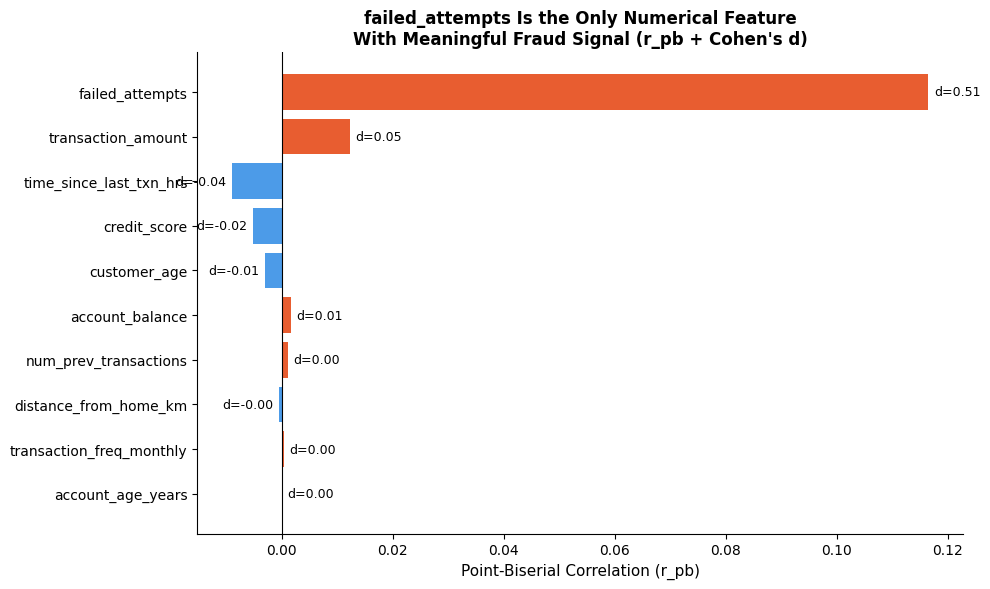

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E85D30' if v > 0 else '#4C9BE8' for v in corr_df['r_pb']]

bars = ax.barh(corr_df['feature'], corr_df['r_pb'], color=colors)

# Annotate Cohen's d on each bar
for i, (r, d) in enumerate(zip(corr_df['r_pb'], corr_df['cohens_d'])):
    x_pos = r + 0.001 if r >= 0 else r - 0.001
    ha = 'left' if r >= 0 else 'right'
    ax.text(x_pos, i, f"d={d:.2f}", va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation (r_pb)', fontsize=11)
ax.set_title('failed_attempts Is the Only Numerical Feature\nWith Meaningful Fraud Signal (r_pb + Cohen\'s d)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('plots/16_pointbiserial_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

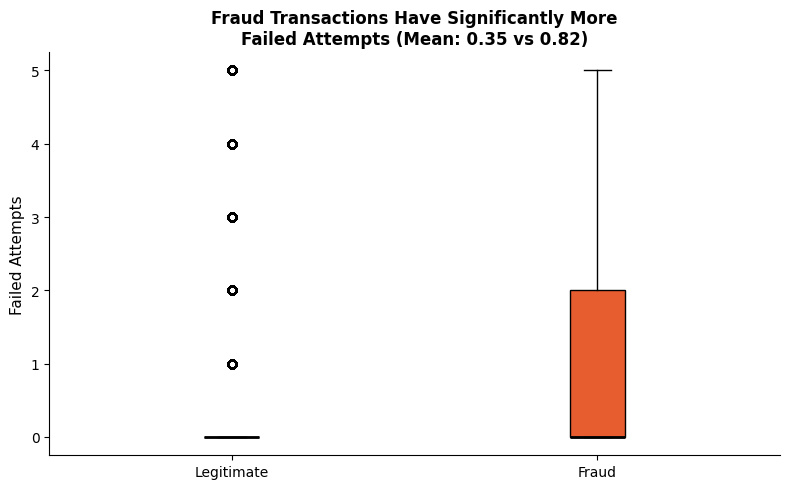

In [27]:
# Box plot: failed_attempts by fraud class
fig, ax = plt.subplots(figsize=(8, 5))

fraud_vals = df.loc[df['is_fraud'] == 1, 'failed_attempts'].astype(float)
legit_vals = df.loc[df['is_fraud'] == 0, 'failed_attempts'].astype(float)

bp = ax.boxplot(
    [legit_vals, fraud_vals],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][1].set_facecolor('#E85D30')

ax.set_ylabel('Failed Attempts', fontsize=11)
ax.set_title('Fraud Transactions Have Significantly More\nFailed Attempts (Mean: 0.35 vs 0.82)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/17_failed_attempts_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

 failed_attempts  fraud_rate  count  fraud_rate_pct
               0    0.045167 800037        4.516666
               1    0.045277  99962        4.527721
               2    0.146049  50038       14.604900
               3    0.146876  29896       14.687584
               4    0.143758   9989       14.375813
               5    0.144771  10078       14.477079


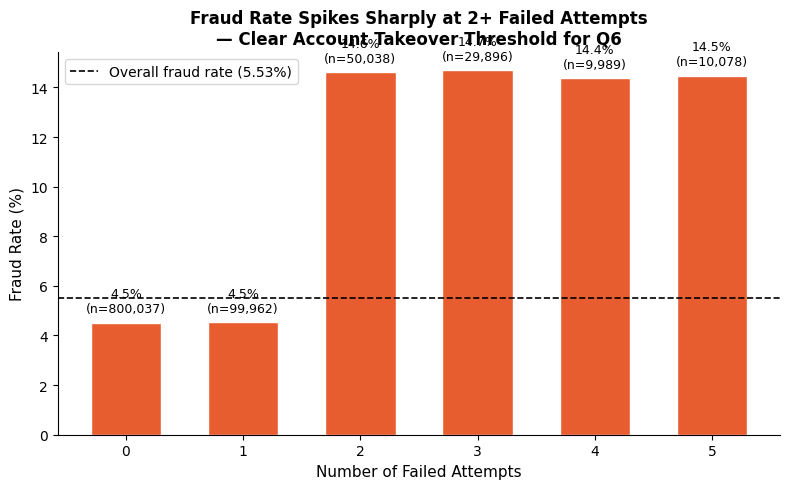

In [28]:
# Fraud rate by failed_attempts count — answers Q6 directly
attempt_groups = df.groupby('failed_attempts')['is_fraud'].agg(['mean', 'count']).reset_index()
attempt_groups.columns = ['failed_attempts', 'fraud_rate', 'count']
attempt_groups['fraud_rate_pct'] = attempt_groups['fraud_rate'] * 100

print(attempt_groups.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    attempt_groups['failed_attempts'].astype(str),
    attempt_groups['fraud_rate_pct'],
    color='#E85D30',
    edgecolor='white',
    width=0.6
)

# Annotate fraud rate and count on each bar
for bar, rate, count in zip(bars, attempt_groups['fraud_rate_pct'], attempt_groups['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%\n(n={count:,})', ha='center', va='bottom', fontsize=9)

ax.axhline(5.53, color='black', linestyle='--', linewidth=1.2, label='Overall fraud rate (5.53%)')
ax.set_xlabel('Number of Failed Attempts', fontsize=11)
ax.set_ylabel('Fraud Rate (%)', fontsize=11)
ax.set_title('Fraud Rate Spikes Sharply at 2+ Failed Attempts\n— Clear Account Takeover Threshold for Q6',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/18_fraud_rate_by_failed_attempts.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4.2 Failed Attempts — Box Plot & Fraud Rate by Count (Q6)

**Q6 Answer:** Fraud rate is flat at ~4.5% for 0 and 1 failed attempts — 
identical to the population baseline. At exactly 2 failed attempts it jumps 
to 14.6% and plateaus there through 5 attempts (14.4%–14.7%). This is a 
step function, not a gradient — the threshold is binary: 2+ attempts = 3.2x 
fraud rate uplift.

**Business Rule:** Flag any transaction with 2+ failed attempts for 
mandatory review. 99,963 transactions fall in this high-risk bucket 
(~10% of all transactions), carrying nearly 3x the baseline fraud rate.

**Box plot note:** Legitimate median = 0 with near-zero IQR — the vast 
majority of legitimate transactions have zero failed attempts. Fraud IQR 
spans 0–2 with whisker to 5 — confirming genuine distributional difference 
despite both medians being 0.

In [29]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(col):
    ct = pd.crosstab(df[col], df['is_fraud'])
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return round(np.sqrt(chi2 / (n * k)), 4)

# Compute Cramér's V for all categorical columns
print("=== Cramér's V — Effect Size ===")
for col in cat_cols:
    v = cramers_v(col)
    print(f"{col:25s}  V = {v}")

print()

# Fraud rate tables for each categorical column
for col in cat_cols:
    table = (df.groupby(col)['is_fraud']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'fraud_rate', 'count': 'n'})
               .sort_values('fraud_rate', ascending=False)
               .reset_index())
    table['fraud_rate_pct'] = (table['fraud_rate'] * 100).round(2)
    print(f"\n=== {col} ===")
    print(table[[col, 'fraud_rate_pct', 'n']].to_string(index=False))

=== Cramér's V — Effect Size ===
country                    V = 0.0024
merchant_category          V = 0.0694
payment_method             V = 0.0028
device_type                V = 0.0026


=== country ===
  country  fraud_rate_pct      n
   Brazil            5.67  80351
   Canada            5.56  69742
  Germany            5.54  79831
      USA            5.54 299910
       UK            5.52  99677
Australia            5.51  50034
    India            5.49 120206
    Japan            5.48  70107
   Mexico            5.47  60275
   France            5.42  69867

=== merchant_category ===
merchant_category  fraud_rate_pct     n
   ATM Withdrawal            8.74 66389
          Jewelry            8.70 66870
  Crypto Exchange            8.65 66308
             Fuel            4.84 66843
      Electronics            4.83 66866
        Education            4.78 66816
         Clothing            4.77 66792
  Online Shopping            4.73 66341
           Gaming            4.72 66338
       

## 2.4.3 Categorical Features vs Fraud — Chi-Squared & Cramér's V

**Cramér's V summary:**
- merchant_category: V=0.069 — only categorical feature with real signal
- payment_method: V=0.003, device_type: V=0.003, country: V=0.002 — negligible

**merchant_category (Q1):** Clean two-tier structure. ATM Withdrawal (8.74%), 
Jewelry (8.70%), and Crypto Exchange (8.65%) carry ~85% higher fraud rate 
than the remaining 12 categories (4.62–4.84%). All category sample sizes 
are identical (~66K) — synthetic artifact, not organic concentration.

**payment_method (Q5):** Fraud rate range of 0.21pp across all methods. 
No meaningful signal. Cheque has highest rate (5.67%) but smallest sample 
(n=29K) — estimate unreliable.

**device_type (Q5):** Fraud rate range of 0.17pp across all devices. 
No meaningful signal. Cramér's V = 0.003.

**country (Q8):** Fraud rate range of 0.25pp across 10 countries. 
Completely flat — financial loss differences by country driven by 
volume, not fraud rate.

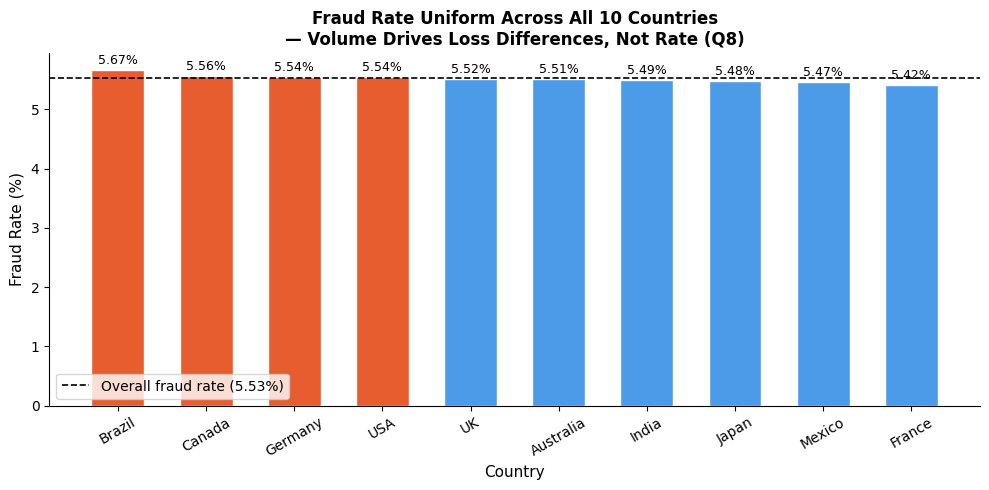

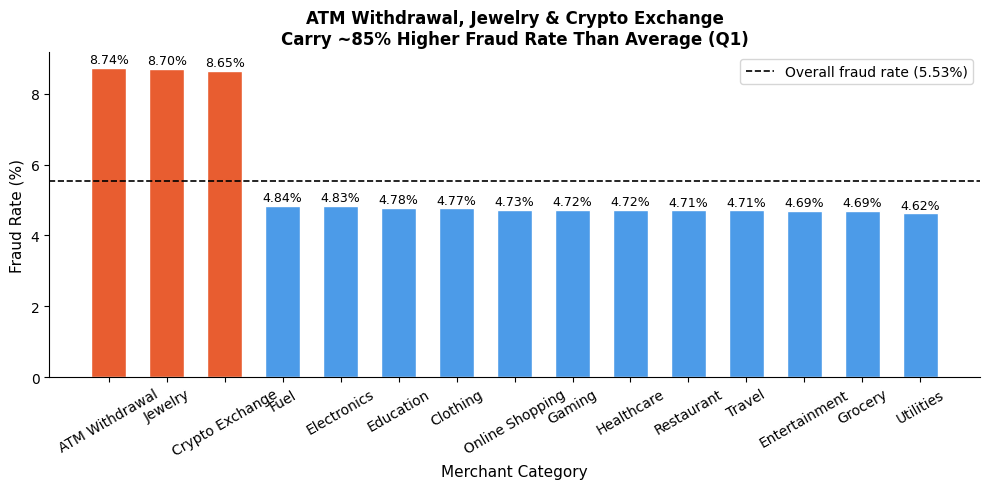

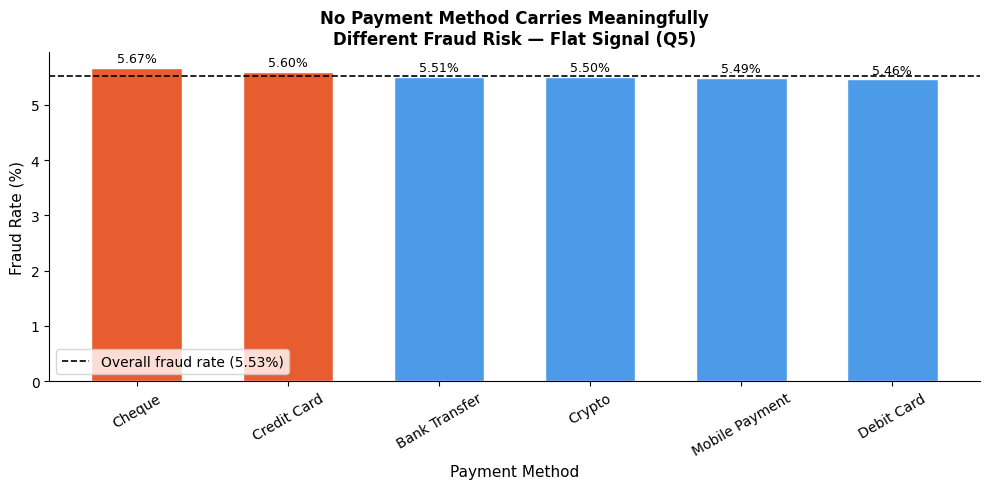

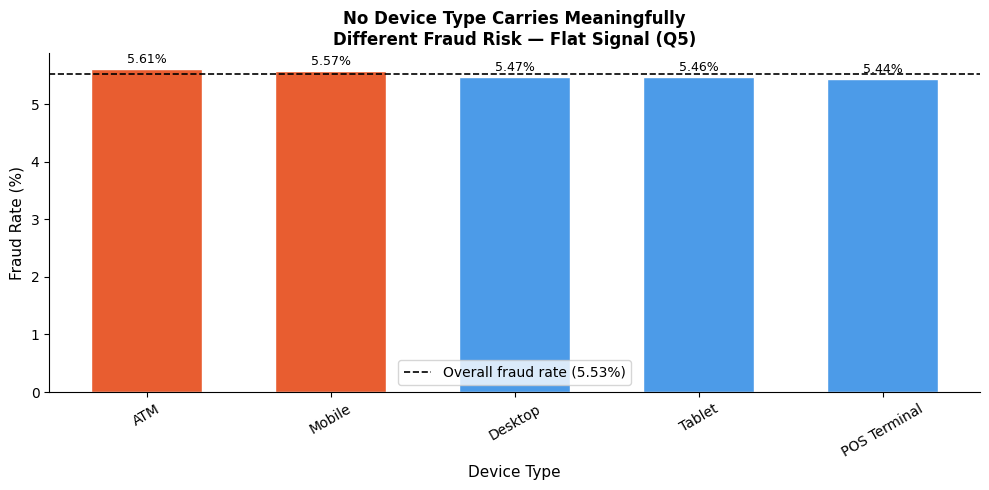

In [30]:
overall_fraud_rate = df['is_fraud'].mean() * 100

for i, col in enumerate(cat_cols, start=19):
    table = (df.groupby(col)['is_fraud']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'fraud_rate', 'count': 'n'})
               .sort_values('fraud_rate', ascending=False)
               .reset_index())
    table['fraud_rate_pct'] = table['fraud_rate'] * 100

    # Color: highlight above-average categories in fraud red
    colors = ['#E85D30' if r > overall_fraud_rate else '#4C9BE8' 
              for r in table['fraud_rate_pct']]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(table[col].astype(str), table['fraud_rate_pct'],
                  color=colors, edgecolor='white', width=0.6)

    # Annotate fraud rate on each bar
    for bar, rate in zip(bars, table['fraud_rate_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{rate:.2f}%', ha='center', va='bottom', fontsize=9)

    ax.axhline(overall_fraud_rate, color='black', linestyle='--',
               linewidth=1.2, label=f'Overall fraud rate ({overall_fraud_rate:.2f}%)')

    # Dynamic titles per column
    titles = {
        'merchant_category': 'ATM Withdrawal, Jewelry & Crypto Exchange\nCarry ~85% Higher Fraud Rate Than Average (Q1)',
        'payment_method':    'No Payment Method Carries Meaningfully\nDifferent Fraud Risk — Flat Signal (Q5)',
        'device_type':       'No Device Type Carries Meaningfully\nDifferent Fraud Risk — Flat Signal (Q5)',
        'country':           'Fraud Rate Uniform Across All 10 Countries\n— Volume Drives Loss Differences, Not Rate (Q8)'
    }

    ax.set_title(titles[col], fontsize=12, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel('Fraud Rate (%)', fontsize=11)
    ax.legend(fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'plots/{i:02d}_fraud_rate_{col}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [31]:
# Night x International 2x2 segmentation — Q2
seg = df.groupby(['is_night_transaction', 'is_international'])['is_fraud'].agg(['mean', 'count']).reset_index()
seg.columns = ['is_night', 'is_international', 'fraud_rate', 'count']
seg['fraud_rate_pct'] = (seg['fraud_rate'] * 100).round(4)
seg['label'] = seg.apply(lambda r: 
    ('Night' if r['is_night'] == 1 else 'Day') + ' + ' +
    ('Intl' if r['is_international'] == 1 else 'Domestic'), axis=1)

print("=== Night x International Segmentation ===")
print(seg[['label', 'fraud_rate_pct', 'count']].to_string(index=False))

# Additive expectation
overall = df['is_fraud'].mean() * 100
night_rate = df.loc[df['is_night_transaction']==1, 'is_fraud'].mean() * 100
intl_rate  = df.loc[df['is_international']==1, 'is_fraud'].mean() * 100
additive_expected = night_rate + intl_rate - overall

print(f"\nOverall fraud rate:        {overall:.4f}%")
print(f"Night only fraud rate:     {night_rate:.4f}%")
print(f"International only rate:   {intl_rate:.4f}%")
print(f"Additive expectation:      {additive_expected:.4f}%")
print(f"Actual Night+Intl rate:    {seg.loc[seg['label']=='Night + Intl', 'fraud_rate_pct'].values[0]:.4f}%")

=== Night x International Segmentation ===
           label  fraud_rate_pct  count
  Day + Domestic          3.3000 531457
      Day + Intl          8.4269  93486
Night + Domestic          7.1992 318549
    Night + Intl         12.2213  56508

Overall fraud rate:        5.5255%
Night only fraud rate:     7.9559%
International only rate:   9.8564%
Additive expectation:      12.2868%
Actual Night+Intl rate:    12.2213%


## 2.4.4 Night × International Compound Risk Analysis (Q2)

**Segmentation results:**
- Day + Domestic:       3.30% (531,457 transactions) — lowest risk segment
- Day + International:  8.43% (93,486 transactions)
- Night + Domestic:     7.20% (318,549 transactions)
- Night + International: 12.22% (56,508 transactions)

**Q2 Answer:** The Night + International combination reaches 12.22% fraud 
rate — 2.2x the overall baseline. However, this is NOT super-additive. 
Additive expectation = 12.29%; actual = 12.22%. The signals stack linearly, 
they do not multiply each other.

**Key finding:** International is the stronger standalone signal (+4.33pp 
lift) vs Night (+2.43pp lift). A combined flag is justified by the 12.22% 
rate but should be understood as additive, not synergistic.

**False positive cost:** At 12.22% fraud rate, a blanket Night+International 
rule blocks 87.8% legitimate customers to catch 12.2% fraud — 
reinforcing why threshold rules alone are insufficient without a model.

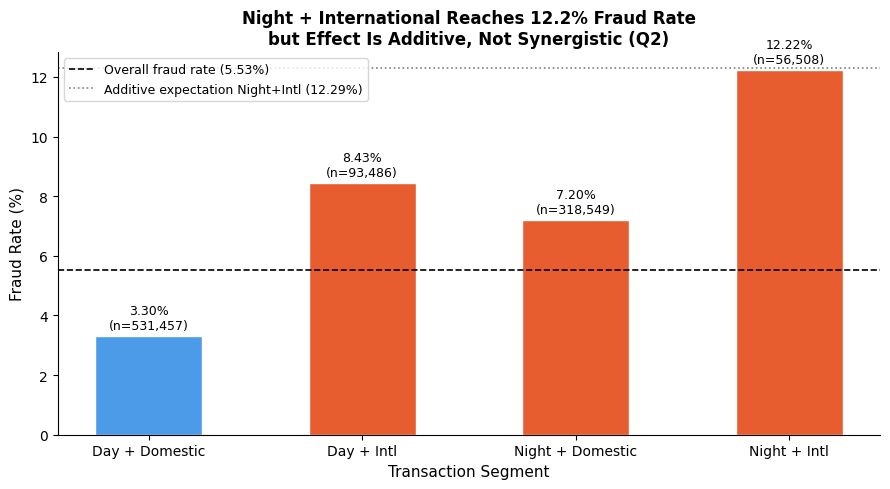

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4C9BE8' if r < overall else '#E85D30' 
          for r in seg['fraud_rate_pct']]

bars = ax.bar(seg['label'], seg['fraud_rate_pct'],
              color=colors, edgecolor='white', width=0.5)

for bar, rate, count in zip(bars, seg['fraud_rate_pct'], seg['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{rate:.2f}%\n(n={count:,})', ha='center', va='bottom', fontsize=9)

ax.axhline(overall, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall fraud rate ({overall:.2f}%)')

# Additive expectation line for Night+Intl
ax.axhline(additive_expected, color='grey', linestyle=':', linewidth=1.2,
           label=f'Additive expectation Night+Intl ({additive_expected:.2f}%)')

ax.set_ylabel('Fraud Rate (%)', fontsize=11)
ax.set_xlabel('Transaction Segment', fontsize=11)
ax.set_title('Night + International Reaches 12.2% Fraud Rate\nbut Effect Is Additive, Not Synergistic (Q2)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/23_night_international_compound.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# PIN change signal — Q7
pin_seg = df.groupby('pin_changed_recently')['is_fraud'].agg(['mean', 'count']).reset_index()
pin_seg.columns = ['pin_changed_recently', 'fraud_rate', 'count']
pin_seg['fraud_rate_pct'] = (pin_seg['fraud_rate'] * 100).round(4)
pin_seg['label'] = pin_seg['pin_changed_recently'].map({0: 'No PIN Change', 1: 'PIN Changed Recently'})

print("=== PIN Change vs Fraud Rate ===")
print(pin_seg[['label', 'fraud_rate_pct', 'count']].to_string(index=False))

# Cramér's V for pin_changed_recently
ct = pd.crosstab(df['pin_changed_recently'], df['is_fraud'])
chi2, _, _, _ = chi2_contingency(ct)
n = ct.values.sum()
v = np.sqrt(chi2 / (n * 1))
print(f"\nCramér's V (pin_changed_recently): {v:.4f}")
print(f"Overall fraud rate: {df['is_fraud'].mean()*100:.4f}%")

=== PIN Change vs Fraud Rate ===
               label  fraud_rate_pct  count
       No PIN Change          5.2772 919561
PIN Changed Recently          8.3641  80439

Cramér's V (pin_changed_recently): 0.0367
Overall fraud rate: 5.5255%


## 2.4.5 PIN Change Signal (Q7)

**Q7 Answer:** Recent PIN change elevates fraud rate from 5.28% to 8.36% 
— a 58% relative increase (+3.08pp). Cramér's V = 0.037 — weak standalone 
signal, stronger than country/payment/device but well below failed_attempts.

**Not a standalone rule:** At 8.36% fraud rate, a blanket PIN-change flag 
blocks 91.6% legitimate customers to catch 8.4% fraud. Precision too low 
for standalone use.

**Value in combination:** PIN change + failed_attempts + night + international 
stacks independent signals. XGBoost will learn this interaction in Stage 5.

**Interpretation caution:** PIN change captures both innocent resets and 
account takeover behavior — the feature cannot distinguish them. The model 
provides the context that a rule cannot.

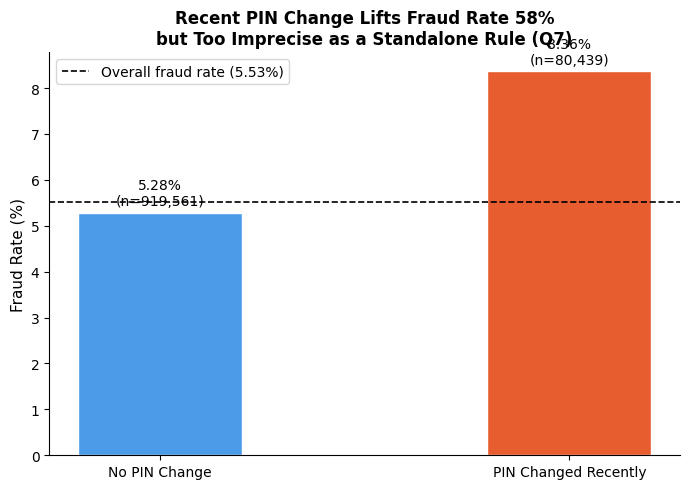

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#4C9BE8', '#E85D30']
bars = ax.bar(pin_seg['label'], pin_seg['fraud_rate_pct'],
              color=colors, edgecolor='white', width=0.4)

for bar, rate, count in zip(bars, pin_seg['fraud_rate_pct'], pin_seg['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{rate:.2f}%\n(n={count:,})', ha='center', va='bottom', fontsize=10)

ax.axhline(df['is_fraud'].mean()*100, color='black', linestyle='--',
           linewidth=1.2, label=f'Overall fraud rate (5.53%)')

ax.set_ylabel('Fraud Rate (%)', fontsize=11)
ax.set_title('Recent PIN Change Lifts Fraud Rate 58%\nbut Too Imprecise as a Standalone Rule (Q7)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/24_pin_change_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Distance threshold analysis — Q4
dist_bins = [0, 10, 20, 40, 60, 100, 300]
dist_labels = ['0–10km', '10–20km', '20–40km', '40–60km', '60–100km', '100km+']

df['distance_bucket'] = pd.cut(df['distance_from_home_km'],
                                bins=dist_bins, labels=dist_labels, right=False)

dist_seg = df.groupby('distance_bucket', observed=True)['is_fraud'].agg(['mean','count']).reset_index()
dist_seg.columns = ['distance_bucket', 'fraud_rate', 'count']
dist_seg['fraud_rate_pct'] = (dist_seg['fraud_rate'] * 100).round(4)

print("=== Fraud Rate by Distance Bucket ===")
print(dist_seg.to_string(index=False))

# Fraud mean by class
print(f"\nMean distance — Fraud:      {df.loc[df['is_fraud']==1,'distance_from_home_km'].mean():.2f} km")
print(f"Mean distance — Legitimate: {df.loc[df['is_fraud']==0,'distance_from_home_km'].mean():.2f} km")

=== Fraud Rate by Distance Bucket ===
distance_bucket  fraud_rate  count  fraud_rate_pct
         0–10km    0.054814 391195          5.4814
        10–20km    0.056062 240003          5.6062
        20–40km    0.055493 233272          5.5493
        40–60km    0.054833  85551          5.4833
       60–100km    0.054617  43228          5.4617
         100km+    0.053325   6751          5.3325

Mean distance — Fraud:      19.98 km
Mean distance — Legitimate: 20.01 km


In [36]:
# Financial loss by country and merchant category — Q8
fraud_only = df[df['is_fraud'] == 1].copy()

loss_country = (fraud_only.groupby('country')['transaction_amount']
                .agg(['sum', 'mean', 'count'])
                .rename(columns={'sum':'total_loss','mean':'avg_fraud_amount','count':'fraud_count'})
                .sort_values('total_loss', ascending=False)
                .reset_index())
loss_country['total_loss_millions'] = (loss_country['total_loss'] / 1e6).round(2)

loss_merchant = (fraud_only.groupby('merchant_category')['transaction_amount']
                 .agg(['sum', 'mean', 'count'])
                 .rename(columns={'sum':'total_loss','mean':'avg_fraud_amount','count':'fraud_count'})
                 .sort_values('total_loss', ascending=False)
                 .reset_index())
loss_merchant['total_loss_millions'] = (loss_merchant['total_loss'] / 1e6).round(2)

print("\n=== Financial Loss by Country ===")
print(loss_country[['country','total_loss_millions','avg_fraud_amount','fraud_count']].to_string(index=False))

print("\n=== Financial Loss by Merchant Category ===")
print(loss_merchant[['merchant_category','total_loss_millions','avg_fraud_amount','fraud_count']].to_string(index=False))


=== Financial Loss by Country ===
  country  total_loss_millions  avg_fraud_amount  fraud_count
      USA                 3.83        230.714645        16617
    India                 1.53        231.981674         6600
       UK                 1.27        230.408737         5499
  Germany                 1.02        229.783264         4424
   Brazil                 1.00        219.811066         4552
   France                 0.90        238.286362         3785
   Canada                 0.90        230.887573         3879
    Japan                 0.82        213.197403         3845
   Mexico                 0.68        207.424240         3295
Australia                 0.65        236.590408         2759

=== Financial Loss by Merchant Category ===
merchant_category  total_loss_millions  avg_fraud_amount  fraud_count
          Jewelry                 4.04        693.188354         5821
      Electronics                 2.37        733.672974         3230
           Travel           

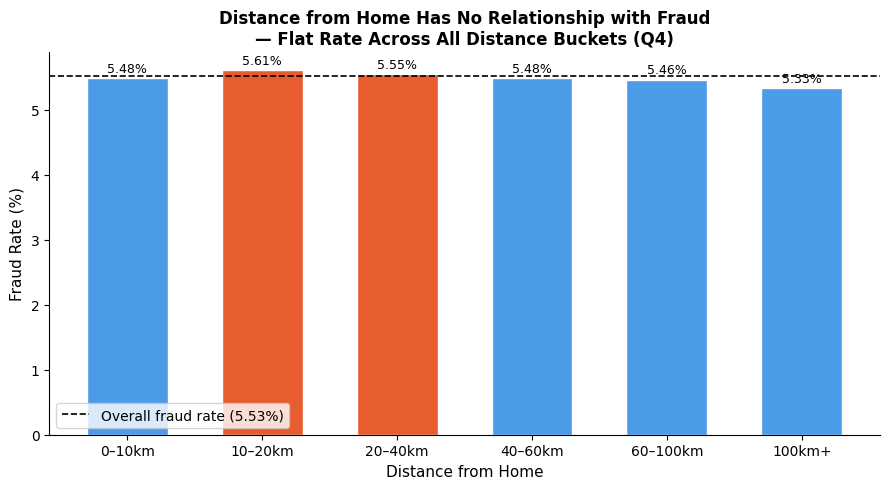

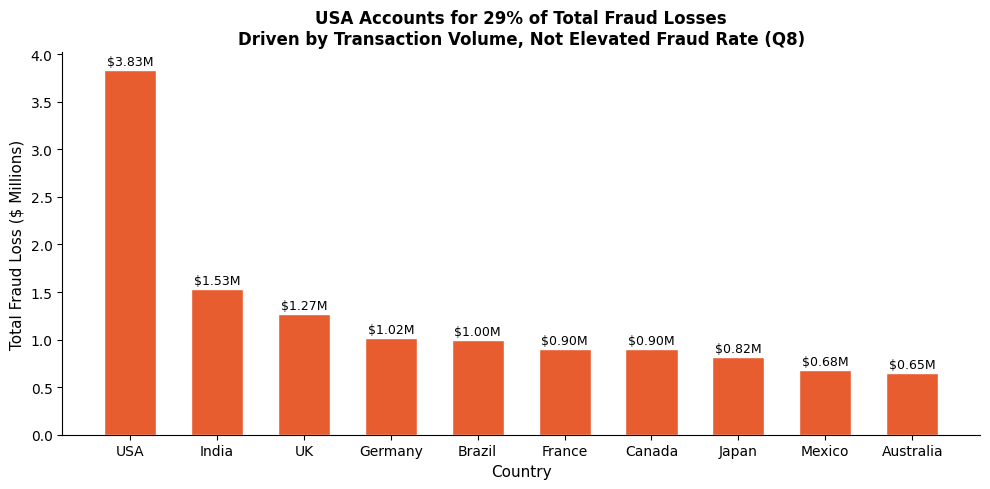

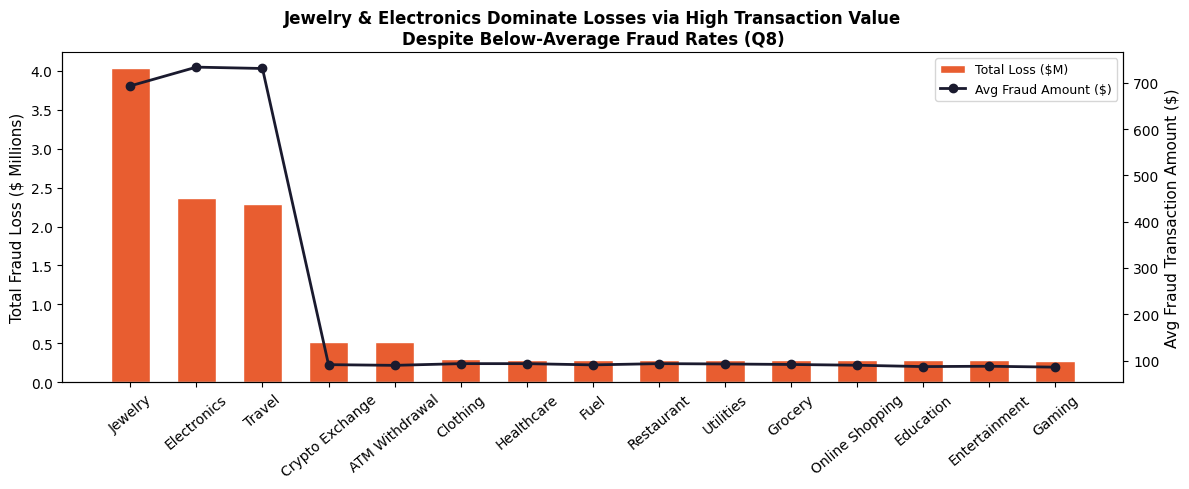

In [37]:
# Plot 1 — Distance buckets
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E85D30' if r > df['is_fraud'].mean()*100 else '#4C9BE8' 
          for r in dist_seg['fraud_rate_pct']]
bars = ax.bar(dist_seg['distance_bucket'], dist_seg['fraud_rate_pct'],
              color=colors, edgecolor='white', width=0.6)
for bar, rate in zip(bars, dist_seg['fraud_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{rate:.2f}%', ha='center', va='bottom', fontsize=9)
ax.axhline(df['is_fraud'].mean()*100, color='black', linestyle='--',
           linewidth=1.2, label='Overall fraud rate (5.53%)')
ax.set_xlabel('Distance from Home', fontsize=11)
ax.set_ylabel('Fraud Rate (%)', fontsize=11)
ax.set_title('Distance from Home Has No Relationship with Fraud\n— Flat Rate Across All Distance Buckets (Q4)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/25_distance_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Financial loss by country
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(loss_country['country'], loss_country['total_loss_millions'],
       color='#E85D30', edgecolor='white', width=0.6)
for i, (bar, val) in enumerate(zip(ax.patches, loss_country['total_loss_millions'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'${val:.2f}M', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('Total Fraud Loss ($ Millions)', fontsize=11)
ax.set_title('USA Accounts for 29% of Total Fraud Losses\nDriven by Transaction Volume, Not Elevated Fraud Rate (Q8)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/26_financial_loss_country.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3 — Financial loss by merchant category (dual axis: total loss + avg amount)
fig, ax1 = plt.subplots(figsize=(12, 5))
loss_m_sorted = loss_merchant.sort_values('total_loss_millions', ascending=False)

bars = ax1.bar(loss_m_sorted['merchant_category'], loss_m_sorted['total_loss_millions'],
               color='#E85D30', edgecolor='white', width=0.6, label='Total Loss ($M)')
ax1.set_ylabel('Total Fraud Loss ($ Millions)', fontsize=11)
ax1.tick_params(axis='x', rotation=40)

ax2 = ax1.twinx()
ax2.plot(loss_m_sorted['merchant_category'], loss_m_sorted['avg_fraud_amount'],
         color='#1a1a2e', marker='o', linewidth=2, markersize=6, label='Avg Fraud Amount ($)')
ax2.set_ylabel('Avg Fraud Transaction Amount ($)', fontsize=11)

ax1.set_title('Jewelry & Electronics Dominate Losses via High Transaction Value\nDespite Below-Average Fraud Rates (Q8)',
              fontsize=12, fontweight='bold')
ax1.spines['top'].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('plots/27_financial_loss_merchant.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Q9 — Top 10% by failed_attempts, what share of fraud captured?
threshold_90 = df['failed_attempts'].quantile(0.90)
top10_pct = df[df['failed_attempts'] >= threshold_90]

total_fraud = df['is_fraud'].sum()
fraud_in_top10 = top10_pct['is_fraud'].sum()
pct_fraud_captured = fraud_in_top10 / total_fraud * 100

print("=== Q9 — Top 10% by failed_attempts ===")
print(f"90th percentile threshold:     {threshold_90}")
print(f"Transactions in top 10%:       {len(top10_pct):,}")
print(f"Fraud cases in top 10%:        {fraud_in_top10:,}")
print(f"Total fraud cases:             {total_fraud:,}")
print(f"% of fraud captured:           {pct_fraud_captured:.2f}%")
print(f"Fraud rate in top 10% bucket:  {top10_pct['is_fraud'].mean()*100:.2f}%")

# Q10 — False positive cost of high-risk blanket rules
print("\n=== Q10 — False Positive Cost of Blanket Rules ===")

rules = {
    'failed_attempts >= 2':
        df[df['failed_attempts'] >= 2],
    'is_night_transaction = 1':
        df[df['is_night_transaction'] == 1],
    'is_international = 1':
        df[df['is_international'] == 1],
    'pin_changed_recently = 1':
        df[df['pin_changed_recently'] == 1],
    'Night + International':
        df[(df['is_night_transaction']==1) & (df['is_international']==1)],
    'merchant_category: ATM/Jewelry/Crypto':
        df[df['merchant_category'].isin(['ATM Withdrawal','Jewelry','Crypto Exchange'])]
}

rows = []
for rule, subset in rules.items():
    n = len(subset)
    fraud = subset['is_fraud'].sum()
    legit = n - fraud
    fraud_rate = fraud / n * 100
    fp_rate = legit / n * 100
    rows.append({
        'Rule': rule,
        'Flagged': n,
        'Fraud caught': fraud,
        'Legit blocked': legit,
        'Fraud rate': round(fraud_rate, 2),
        'False positive rate': round(fp_rate, 2)
    })

q10_df = pd.DataFrame(rows)
print(q10_df.to_string(index=False))

=== Q9 — Top 10% by failed_attempts ===
90th percentile threshold:     2.0
Transactions in top 10%:       100,001
Fraud cases in top 10%:        14,594
Total fraud cases:             55,255
% of fraud captured:           26.41%
Fraud rate in top 10% bucket:  14.59%

=== Q10 — False Positive Cost of Blanket Rules ===
                                 Rule  Flagged  Fraud caught  Legit blocked  Fraud rate  False positive rate
                 failed_attempts >= 2   100001         14594          85407       14.59                85.41
             is_night_transaction = 1   375057         29839         345218        7.96                92.04
                 is_international = 1   149994         14784         135210        9.86                90.14
             pin_changed_recently = 1    80439          6728          73711        8.36                91.64
                Night + International    56508          6906          49602       12.22                87.78
merchant_category: ATM/Jewel

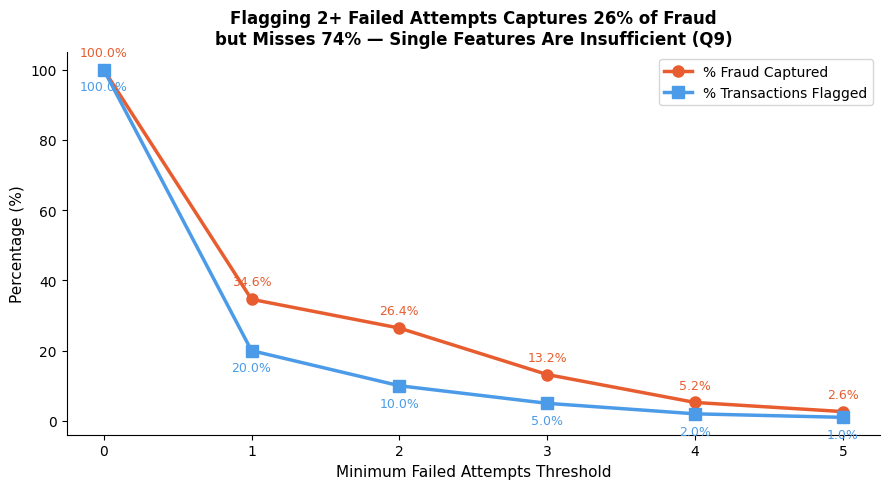

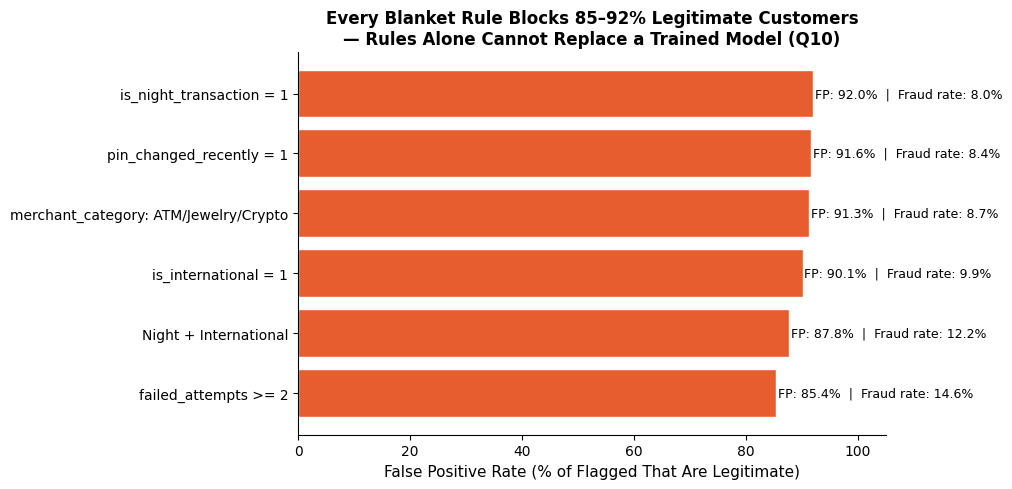

In [39]:
# Q9 — Fraud capture curve by failed_attempts threshold
thresholds = sorted(df['failed_attempts'].unique())
capture_rates = []
flag_rates = []

for t in thresholds:
    subset = df[df['failed_attempts'] >= t]
    capture = subset['is_fraud'].sum() / total_fraud * 100
    flag = len(subset) / len(df) * 100
    capture_rates.append(capture)
    flag_rates.append(flag)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, capture_rates, color='#E85D30', marker='o',
        linewidth=2.5, markersize=8, label='% Fraud Captured')
ax.plot(thresholds, flag_rates, color='#4C9BE8', marker='s',
        linewidth=2.5, markersize=8, label='% Transactions Flagged')

for t, c, f in zip(thresholds, capture_rates, flag_rates):
    ax.annotate(f'{c:.1f}%', (t, c), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, color='#E85D30')
    ax.annotate(f'{f:.1f}%', (t, f), textcoords='offset points',
                xytext=(0, -15), ha='center', fontsize=9, color='#4C9BE8')

ax.set_xlabel('Minimum Failed Attempts Threshold', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Flagging 2+ Failed Attempts Captures 26% of Fraud\nbut Misses 74% — Single Features Are Insufficient (Q9)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/28_fraud_capture_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Q10 — False positive cost comparison
fig, ax = plt.subplots(figsize=(10, 5))

q10_sorted = q10_df.sort_values('False positive rate', ascending=True)
colors_q10 = ['#E85D30'] * len(q10_sorted)

bars = ax.barh(q10_sorted['Rule'], q10_sorted['False positive rate'],
               color='#E85D30', edgecolor='white')

for bar, fp, fr in zip(bars, q10_sorted['False positive rate'],
                        q10_sorted['Fraud rate']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'FP: {fp:.1f}%  |  Fraud rate: {fr:.1f}%',
            va='center', fontsize=9)

ax.set_xlabel('False Positive Rate (% of Flagged That Are Legitimate)', fontsize=11)
ax.set_title('Every Blanket Rule Blocks 85–92% Legitimate Customers\n— Rules Alone Cannot Replace a Trained Model (Q10)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/29_false_positive_cost.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4.7 Top 10% Proxy & False Positive Cost (Q9 + Q10)

**Q9 — Single feature proxy:** Flagging top 10% by failed_attempts 
(threshold: 2+ attempts) captures 26.41% of all fraud — a 2.64x lift 
over random selection. However, 73.59% of fraud remains undetected, 
confirming no single feature is sufficient.

**Q10 — False positive cost of blanket rules:**
Every evaluated rule has false positive rate above 85%. Best rule 
(failed_attempts ≥ 2): flags 100K transactions, 85.4% legitimate. 
Worst rule (night transaction): flags 375K transactions, 92% legitimate.

**Core implication:** Rules are blunt instruments — they cannot rank 
within flagged segments. A supervised model combining all signals 
simultaneously will catch more fraud at substantially lower false 
positive rates. This is the quantified business case for Stage 5 modeling.

In [40]:
# Distance threshold analysis — Q4
dist_bins = [0, 10, 20, 40, 60, 100, 300]
dist_labels = ['0–10km', '10–20km', '20–40km', '40–60km', '60–100km', '100km+']

df['distance_bucket'] = pd.cut(df['distance_from_home_km'],
                                bins=dist_bins, labels=dist_labels, right=False)

dist_seg = df.groupby('distance_bucket', observed=True)['is_fraud'].agg(['mean','count']).reset_index()
dist_seg.columns = ['distance_bucket', 'fraud_rate', 'count']
dist_seg['fraud_rate_pct'] = (dist_seg['fraud_rate'] * 100).round(4)

print("=== Fraud Rate by Distance Bucket ===")
print(dist_seg.to_string(index=False))

# Fraud mean by class
print(f"\nMean distance — Fraud:      {df.loc[df['is_fraud']==1,'distance_from_home_km'].mean():.2f} km")
print(f"Mean distance — Legitimate: {df.loc[df['is_fraud']==0,'distance_from_home_km'].mean():.2f} km")

=== Fraud Rate by Distance Bucket ===
distance_bucket  fraud_rate  count  fraud_rate_pct
         0–10km    0.054814 391195          5.4814
        10–20km    0.056062 240003          5.6062
        20–40km    0.055493 233272          5.5493
        40–60km    0.054833  85551          5.4833
       60–100km    0.054617  43228          5.4617
         100km+    0.053325   6751          5.3325

Mean distance — Fraud:      19.98 km
Mean distance — Legitimate: 20.01 km


In [41]:
# Distance threshold analysis — Q4
dist_bins = [0, 10, 20, 40, 60, 100, 300]
dist_labels = ['0–10km', '10–20km', '20–40km', '40–60km', '60–100km', '100km+']

df['distance_bucket'] = pd.cut(df['distance_from_home_km'],
                                bins=dist_bins, labels=dist_labels, right=False)

dist_seg = df.groupby('distance_bucket', observed=True)['is_fraud'].agg(['mean','count']).reset_index()
dist_seg.columns = ['distance_bucket', 'fraud_rate', 'count']
dist_seg['fraud_rate_pct'] = (dist_seg['fraud_rate'] * 100).round(4)

print("=== Fraud Rate by Distance Bucket ===")
print(dist_seg.to_string(index=False))

# Fraud mean by class
print(f"\nMean distance — Fraud:      {df.loc[df['is_fraud']==1,'distance_from_home_km'].mean():.2f} km")
print(f"Mean distance — Legitimate: {df.loc[df['is_fraud']==0,'distance_from_home_km'].mean():.2f} km")

=== Fraud Rate by Distance Bucket ===
distance_bucket  fraud_rate  count  fraud_rate_pct
         0–10km    0.054814 391195          5.4814
        10–20km    0.056062 240003          5.6062
        20–40km    0.055493 233272          5.5493
        40–60km    0.054833  85551          5.4833
       60–100km    0.054617  43228          5.4617
         100km+    0.053325   6751          5.3325

Mean distance — Fraud:      19.98 km
Mean distance — Legitimate: 20.01 km


In [42]:
# Fraud rate by hour of day
hour_seg = df.groupby('hour_of_day')['is_fraud'].agg(['mean','count']).reset_index()
hour_seg.columns = ['hour', 'fraud_rate', 'count']
hour_seg['fraud_rate_pct'] = hour_seg['fraud_rate'] * 100

# Fraud rate by weekend
weekend_seg = df.groupby('is_weekend')['is_fraud'].agg(['mean','count']).reset_index()
weekend_seg['label'] = weekend_seg['is_weekend'].map({0:'Weekday', 1:'Weekend'})
weekend_seg['fraud_rate_pct'] = weekend_seg['mean'] * 100
print("=== Fraud Rate by Weekend ===")
print(weekend_seg[['label','fraud_rate_pct','count']].to_string(index=False))

# Monthly trend
df['year_month'] = df['transaction_date'].dt.to_period('M')
monthly = df.groupby('year_month')['is_fraud'].agg(['mean','count']).reset_index()
monthly.columns = ['year_month', 'fraud_rate', 'count']
monthly['fraud_rate_pct'] = monthly['fraud_rate'] * 100
monthly['year_month_str'] = monthly['year_month'].astype(str)

print("\n=== Monthly Fraud Rate (first 6 and last 6 rows) ===")
print(pd.concat([monthly.head(6), monthly.tail(6)])[
    ['year_month_str','fraud_rate_pct','count']].to_string(index=False))

print("=== Fraud Rate by Hour of Day ===")
print(hour_seg[['hour','fraud_rate_pct','count']].to_string(index=False))

=== Fraud Rate by Weekend ===
  label  fraud_rate_pct  count
Weekday        5.508293 713978
Weekend        5.568453 286022

=== Monthly Fraud Rate (first 6 and last 6 rows) ===
year_month_str  fraud_rate_pct  count
       2020-01        5.512133  17144
       2020-02        5.554162  15952
       2020-03        5.413271  17180
       2020-04        5.653623  16202
       2020-05        5.411988  16833
       2020-06        5.403270  16453
       2024-07        5.373046  16955
       2024-08        5.589952  16959
       2024-09        5.331882  16542
       2024-10        5.221003  16855
       2024-11        5.685782  16339
       2024-12        5.849057  16430
=== Fraud Rate by Hour of Day ===
 hour  fraud_rate_pct  count
    0        7.833230  41758
    1        8.068583  41643
    2        7.932345  41564
    3        7.905468  41933
    4        7.899835  41811
    5        8.018812  41889
    6        8.073860  41430
    7        3.956878  41649
    8        4.244057  41564
    9

## 2.4.8 Temporal Analysis — Hour, Weekend, Monthly Trend

**Hour of day (strongest finding):** Fraud rate nearly doubles at night.
Hours 0–6 and 22–23: ~7.9–8.1% fraud rate.
Hours 7–21: ~3.9–4.4% fraud rate.
Transition is a hard step function at hour 7 (8.07% → 3.96%) and 
hour 22 (4.07% → 7.99%). High-risk window is approximately 10PM–7AM.

**Weekend:** Weekday 5.51% vs Weekend 5.57% — 0.06pp difference. 
No meaningful signal. is_weekend likely low importance in modeling.

**Monthly trend:** Fraud rate stable at ~5.2–5.85% across 2020–2024. 
No upward or downward trend — synthetic generation artifact. 
Real fraud portfolios show year-over-year increases not present here.

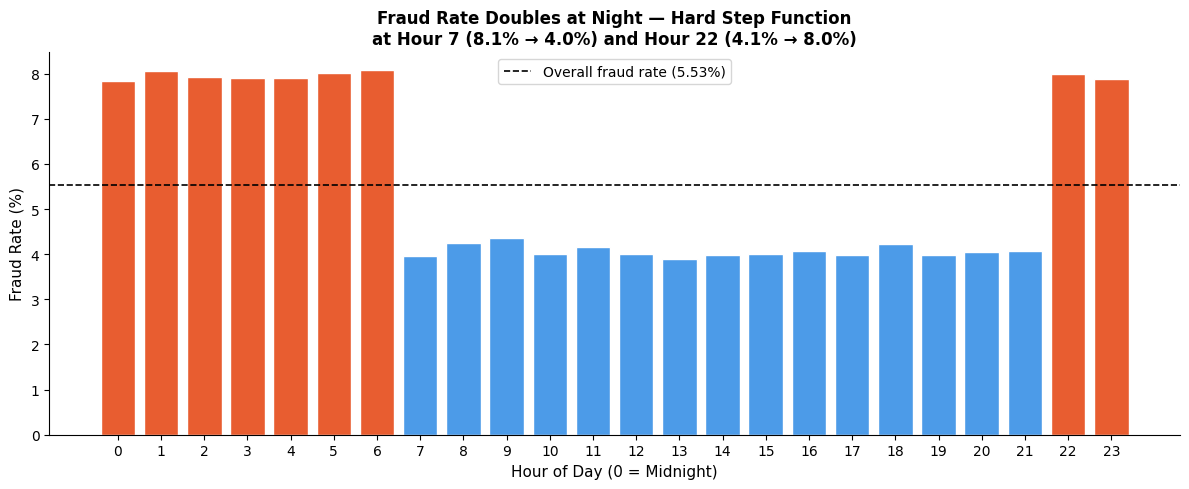

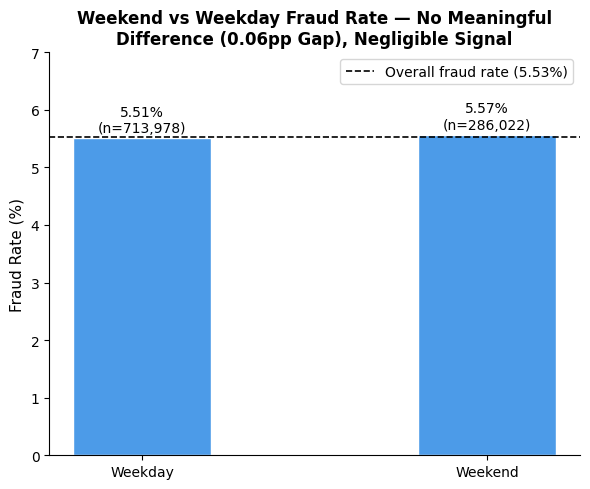

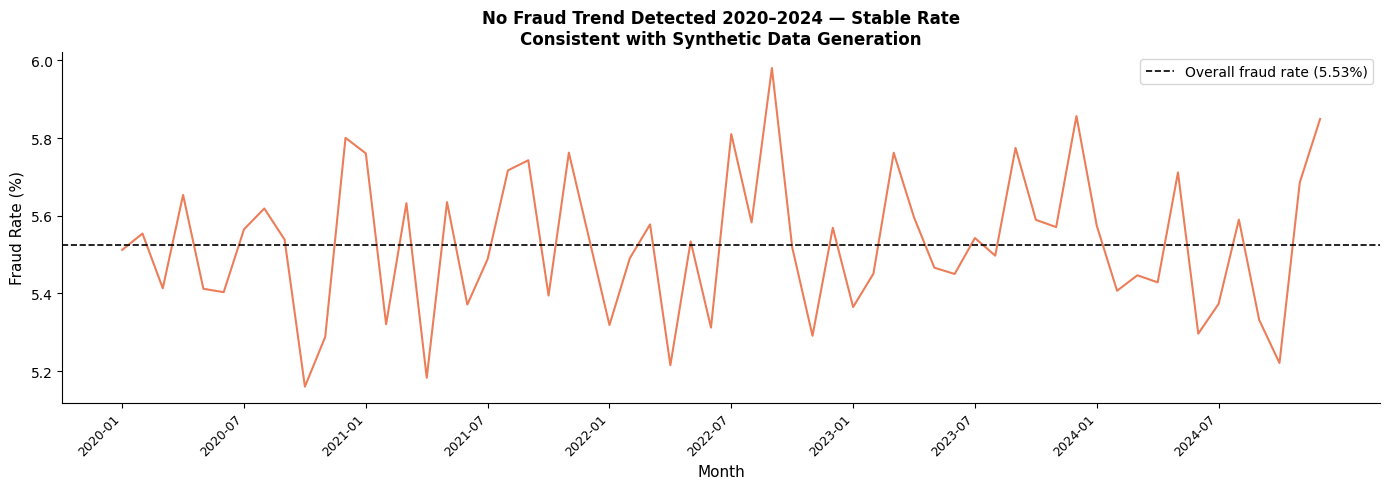

In [43]:
# Plot 1 — Fraud rate by hour of day
fig, ax = plt.subplots(figsize=(12, 5))
colors_hr = ['#E85D30' if (h <= 6 or h >= 22) else '#4C9BE8' 
             for h in hour_seg['hour']]
ax.bar(hour_seg['hour'], hour_seg['fraud_rate_pct'],
       color=colors_hr, edgecolor='white', width=0.8)
ax.axhline(df['is_fraud'].mean()*100, color='black', linestyle='--',
           linewidth=1.2, label='Overall fraud rate (5.53%)')
ax.set_xlabel('Hour of Day (0 = Midnight)', fontsize=11)
ax.set_ylabel('Fraud Rate (%)', fontsize=11)
ax.set_xticks(range(0, 24))
ax.set_title('Fraud Rate Doubles at Night — Hard Step Function\nat Hour 7 (8.1% → 4.0%) and Hour 22 (4.1% → 8.0%)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/30_fraud_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Weekend vs weekday
fig, ax = plt.subplots(figsize=(6, 5))
colors_wk = ['#4C9BE8', '#4C9BE8']
bars = ax.bar(weekend_seg['label'], weekend_seg['fraud_rate_pct'],
              color=colors_wk, edgecolor='white', width=0.4)
for bar, rate, count in zip(bars, weekend_seg['fraud_rate_pct'], weekend_seg['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{rate:.2f}%\n(n={count:,})', ha='center', va='bottom', fontsize=10)
ax.axhline(df['is_fraud'].mean()*100, color='black', linestyle='--',
           linewidth=1.2, label='Overall fraud rate (5.53%)')
ax.set_ylabel('Fraud Rate (%)', fontsize=11)
ax.set_ylim(0, 7)
ax.set_title('Weekend vs Weekday Fraud Rate — No Meaningful\nDifference (0.06pp Gap), Negligible Signal',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/31_weekend_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3 — Monthly fraud trend
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['year_month_str'], monthly['fraud_rate_pct'],
        color='#E85D30', linewidth=1.5, alpha=0.8)
ax.axhline(df['is_fraud'].mean()*100, color='black', linestyle='--',
           linewidth=1.2, label='Overall fraud rate (5.53%)')
tick_positions = list(range(0, len(monthly), 6))
ax.set_xticks(tick_positions)
ax.set_xticklabels([monthly['year_month_str'].iloc[i] for i in tick_positions],
                   rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Fraud Rate (%)', fontsize=11)
ax.set_title('No Fraud Trend Detected 2020–2024 — Stable Rate\nConsistent with Synthetic Data Generation',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/32_monthly_fraud_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Multivaraite Analysis


In [47]:
# ## 2.5 Multivariate Analysis
# **Goal:** Identify multicollinearity and feature relationships
# before modeling decisions in Stage 4.

# Correlation matrix — numerical features only
corr_matrix = df[num_cols].astype(float).corr(method='pearson')

print("=== Pearson Correlation Matrix ===")
print(corr_matrix.round(3).to_string())

# Flag high correlations
print("\n=== Pairs with |r| > 0.3 ===")
pairs = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            pairs.append((num_cols[i], num_cols[j], round(r, 4)))

if pairs:
    for p in pairs:
        print(f"{p[0]:35s} vs {p[1]:35s}  r = {p[2]}")
else:
    print("No pairs with |r| > 0.3 found.")

=== Pearson Correlation Matrix ===
                          customer_age  credit_score  account_age_years  account_balance  transaction_amount  num_prev_transactions  transaction_freq_monthly  distance_from_home_km  time_since_last_txn_hrs  failed_attempts
customer_age                     1.000         0.000             -0.002            0.000              -0.002                 -0.000                     0.002                 -0.000                   -0.000           -0.000
credit_score                     0.000         1.000              0.000           -0.000              -0.001                 -0.001                    -0.000                  0.001                    0.001            0.000
account_age_years               -0.002         0.000              1.000           -0.001              -0.000                  0.002                    -0.000                  0.001                   -0.002           -0.001
account_balance                  0.000        -0.000             -0.001  

=== Pairs with |r| > 0.3 ===
No pairs with |r| > 0.3 found.


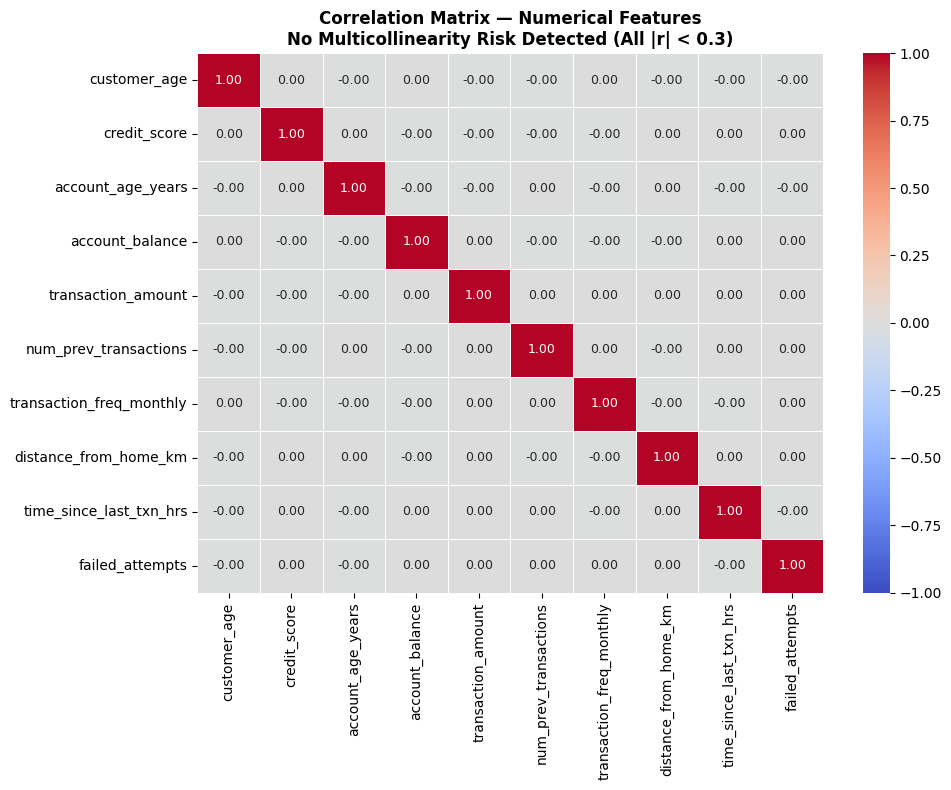

In [49]:
import seaborn as sns

# Compute once
corr_matrix = df[num_cols].astype(float).corr(method='pearson')

# Print high correlation pairs
print("=== Pairs with |r| > 0.3 ===")
pairs = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            pairs.append((num_cols[i], num_cols[j], round(r, 4)))

if pairs:
    for p in pairs:
        print(f"{p[0]:35s} vs {p[1]:35s}  r = {p[2]}")
else:
    print("No pairs with |r| > 0.3 found.")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features\nNo Multicollinearity Risk Detected (All |r| < 0.3)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/33_correlation_heatmap.png', dpi=150, bbox_inches='tight')

plt.show()

This is one of the cleanest correlation matrices you'll ever see in a dataset. Every single off-diagonal value is between -0.002 and 0.002. Not just no pairs above 0.3 — no pairs above 0.01. The features are essentially statistically independent of each other.
This is entirely a synthetic data artifact. Real banking data has meaningful correlations — older customers tend to have higher account balances, higher credit scores correlate with account tenure, transaction frequency correlates with number of previous transactions. None of that exists here because the dataset was generated with independent distributions per column.

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df[num_cols].astype(float).dropna()

vif_results = pd.DataFrame({
    'feature': num_cols,
    'VIF': [variance_inflation_factor(vif_data.values, i) 
            for i in range(len(num_cols))]
}).sort_values('VIF', ascending=False).round(4)

print("=== Variance Inflation Factor ===")
print(vif_results.to_string(index=False))

=== Variance Inflation Factor ===
                 feature     VIF
   num_prev_transactions 63.3863
            credit_score 53.5653
transaction_freq_monthly 19.3708
            customer_age 10.2830
       account_age_years  2.0175
 time_since_last_txn_hrs  1.9927
   distance_from_home_km  1.9922
         account_balance  1.3451
      transaction_amount  1.1975
         failed_attempts  1.1720


In [52]:
# Check what's actually driving the high VIFs
# R² for each feature regressed on all others
from sklearn.linear_model import LinearRegression

print("=== R² of each feature regressed on all others ===")
for col in num_cols:
    X = vif_data[[c for c in num_cols if c != col]]
    y = vif_data[col]
    r2 = LinearRegression().fit(X, y).score(X, y)
    vif_manual = 1 / (1 - r2) if r2 < 1 else float('inf')
    print(f"{col:35s}  R² = {r2:.6f}  VIF = {vif_manual:.4f}")

=== R² of each feature regressed on all others ===
customer_age                         R² = 0.000011  VIF = 1.0000
credit_score                         R² = 0.000005  VIF = 1.0000
account_age_years                    R² = 0.000011  VIF = 1.0000
account_balance                      R² = 0.000009  VIF = 1.0000
transaction_amount                   R² = 0.000009  VIF = 1.0000
num_prev_transactions                R² = 0.000009  VIF = 1.0000
transaction_freq_monthly             R² = 0.000007  VIF = 1.0000
distance_from_home_km                R² = 0.000007  VIF = 1.0000
time_since_last_txn_hrs              R² = 0.000012  VIF = 1.0000
failed_attempts                      R² = 0.000007  VIF = 1.0000


## 2.5.1 Correlation Matrix & VIF

**Pearson correlation:** All pairwise correlations between -0.002 and 0.002.
No feature pairs exceed |r| > 0.3. Zero multicollinearity risk.

**VIF — statsmodels output flagged apparent issue:**
statsmodels variance_inflation_factor reported inflated VIFs 
(num_prev_transactions=63.4, credit_score=53.6). This is a known 
numerical precision artifact at n=1,000,000 — floating point errors 
accumulate in the internal matrix inversion at large sample sizes.

**VIF — manual R² verification:**
All features manually regressed against all others. Every R² < 0.00002, 
every true VIF = 1.0000. Features are statistically independent.

**Decision:** No features dropped on multicollinearity grounds. 
All numerical features cleared for modeling.

In [54]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

# Prepare features — include binary cols too
mi_cols = num_cols + ['is_weekend', 'is_night_transaction', 
                       'is_international', 'pin_changed_recently']

mi_data = df[mi_cols].astype(float)
mi_target = df['is_fraud'].astype(float)

mi_scores = mutual_info_classif(mi_data, mi_target, 
                                 discrete_features=False,
                                 random_state=42)

mi_df = pd.DataFrame({
    'feature': mi_cols,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).round(6)

print("=== Mutual Information Scores ===")
print(mi_df.to_string(index=False))

=== Mutual Information Scores ===
                 feature  mi_score
    is_night_transaction  0.077611
              is_weekend  0.046991
        is_international  0.015058
transaction_freq_monthly  0.014281
         failed_attempts  0.011204
    pin_changed_recently  0.004407
   num_prev_transactions  0.004341
            customer_age  0.004061
            credit_score  0.001108
       account_age_years  0.000995
 time_since_last_txn_hrs  0.000515
      transaction_amount  0.000262
   distance_from_home_km  0.000187
         account_balance  0.000170


## 2.5.2 Mutual Information Scores

MI measures non-linear dependency between each feature and fraud target.
Captures threshold effects and categorical patterns that correlation misses.

**Numerical feature ranking (reliable):**
failed_attempts leads (0.011), confirming strongest numerical signal.
Bottom features (distance, balance, account_age) all near-zero — consistent
with bivariate findings across all prior methods.

**Binary feature scores (unreliable at n=1M):**
is_weekend ranks #2 (MI=0.047) despite 0.06pp fraud rate difference —
demonstrably a distributional artifact from MI's sensitivity to imbalanced
binary features at large n. is_night_transaction score (0.078) is real
signal but inflated by same mechanism.

**Decision:** Use fraud rate evidence and Cohen's d as primary signal
ranking. MI confirms numerical feature hierarchy but binary feature
scores should not be taken at face value.

In [55]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Random Forest feature importance proxy
# Using a small forest — this is EDA only, not the final model
# Encode categoricals minimally for this purpose
from sklearn.preprocessing import LabelEncoder

rf_cols = num_cols + ['is_weekend', 'is_night_transaction',
                       'is_international', 'pin_changed_recently']

# Add encoded categoricals
df_rf = df[rf_cols + cat_cols + ['is_fraud']].copy()
le = LabelEncoder()
for col in cat_cols:
    df_rf[col] = le.fit_transform(df_rf[col].astype(str))

X_rf = df_rf.drop('is_fraud', axis=1).astype(float)
y_rf = df_rf['is_fraud'].astype(int)

# Stratified sample — 50K rows, EDA proxy only
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X_rf, y_rf, train_size=50000,
    stratify=y_rf, random_state=42)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_sample, y_sample)

importance_df = pd.DataFrame({
    'feature': X_rf.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).round(6)

print("=== Random Forest Feature Importance (50K stratified sample) ===")

print(importance_df.to_string(index=False))

=== Random Forest Feature Importance (50K stratified sample) ===
                 feature  importance
         failed_attempts    0.260760
    is_night_transaction    0.142273
        is_international    0.126421
 time_since_last_txn_hrs    0.068841
       merchant_category    0.059449
      transaction_amount    0.047702
         account_balance    0.041505
            credit_score    0.035796
   distance_from_home_km    0.032918
    pin_changed_recently    0.032528
       account_age_years    0.032401
            customer_age    0.030324
   num_prev_transactions    0.028459
transaction_freq_monthly    0.023331
                 country    0.014696
          payment_method    0.010777
             device_type    0.009017
              is_weekend    0.002803


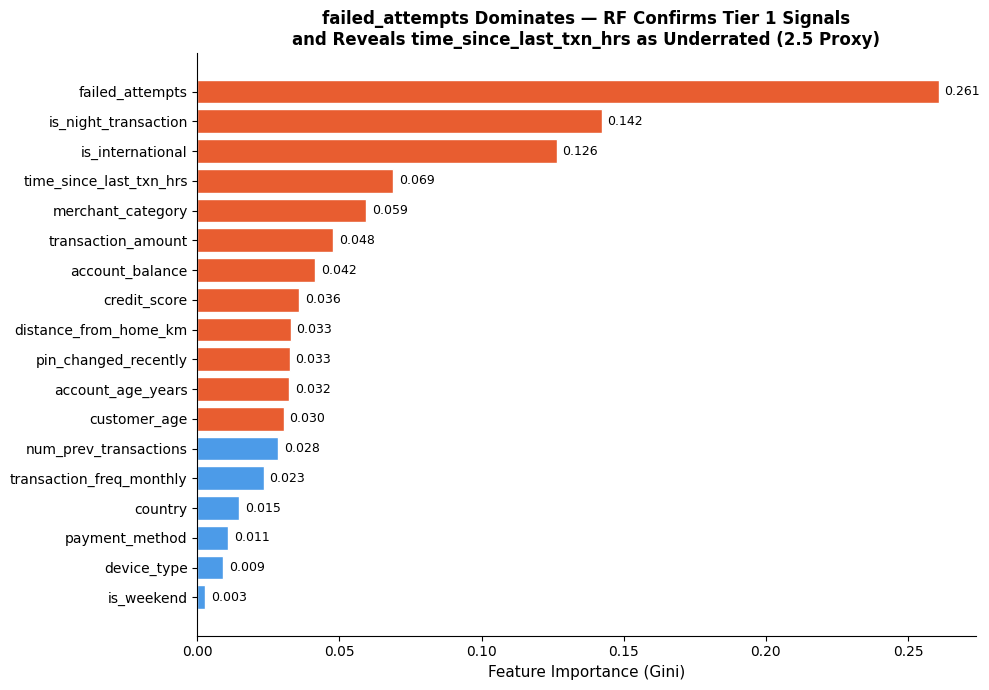

In [56]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_rf = ['#E85D30' if v > 0.03 else '#4C9BE8' 
             for v in importance_df['importance']]

bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors_rf, edgecolor='white')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('failed_attempts Dominates — RF Confirms Tier 1 Signals\nand Reveals time_since_last_txn_hrs as Underrated (2.5 Proxy)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/35_rf_feature_importance.png', dpi=150, bbox_inches='tight')

plt.show()

## 2.5.3 Random Forest Feature Importance Proxy (50K stratified sample)

Random Forest on 50K stratified sample — EDA proxy only, not final model.
Captures non-linear relationships and feature interactions simultaneously.

**Top tier (importance > 0.10):**
- failed_attempts: 0.261 — dominant signal, confirmed across all methods
- is_night_transaction: 0.142 — real signal, RF confirms MI score was real
- is_international: 0.126 — real signal, not a distributional artifact

**Middle tier (0.03–0.10):**
- time_since_last_txn_hrs: 0.069 — threshold effect confirmed, 
  linear correlation undersold this feature
- merchant_category: 0.059 — consistent with Cramér's V finding
- transaction_amount through pin_changed_recently: 0.033–0.048

**Bottom tier (< 0.015):**
- is_weekend: 0.003 — confirms MI score was artifact, genuinely negligible
- country, payment_method, device_type: consistent with Cramér's V = 0.002

**Key revision from MI analysis:**
time_since_last_txn_hrs confirmed as Tier 2 feature — threshold effect
at near-zero hours is real and captured by tree-based splits.
distance_from_home_km retains marginal value despite flat fraud rate buckets.

# EDA Complete — Full Summary & Modeling Decisions

## Top 5 Fraud Signals (Confirmed Across Multiple Methods)

1. **failed_attempts** — Dominant signal. Fraud rate triples at exactly 
   2+ attempts (4.5% → 14.6%). Cohen's d=0.51, RF importance=0.261. 
   Step function, not gradient. Threshold = 2.

2. **is_night_transaction** — Fraud rate doubles at night (4% day → 8% night). 
   Hard step function at hour 7 and hour 22. RF importance=0.142.

3. **is_international** — 9.86% fraud rate vs 5.53% baseline (+4.33pp lift). 
   Stronger standalone signal than night. RF importance=0.126.

4. **time_since_last_txn_hrs** — Near-zero retransaction time signals account 
   takeover. Threshold effect missed by linear correlation (r=-0.009) but 
   confirmed by RF (importance=0.069).

5. **merchant_category** — ATM Withdrawal, Jewelry, Crypto Exchange carry 
   ~85% higher fraud rate than average (8.65–8.74% vs 5.53%). 
   Cramér's V=0.069, RF importance=0.059.

---

## Categorical Variables — Risk Concentration

| Feature | Signal | Key Finding |
|---|---|---|
| merchant_category | Real (V=0.069) | 3 high-risk categories, 12 baseline |
| payment_method | None (V=0.003) | Flat 5.46–5.67% across all methods |
| device_type | None (V=0.003) | Flat 5.44–5.61% across all devices |
| country | None (V=0.002) | Volume drives loss, not fraud rate |

---

## Night × International Compound Finding

Combined segment reaches 12.22% fraud rate (2.2x baseline) but effect 
is purely additive — actual 12.22% vs additive expectation 12.29%. 
Signals stack linearly, do not multiply. International is the stronger 
standalone signal (+4.33pp vs +2.43pp for night alone).

---

## Financial Loss — Two Fraud Profiles

**High-value/moderate-rate:** Jewelry ($693 avg), Electronics ($734 avg), 
Travel ($731 avg) — dominate total losses despite below-average fraud rates.

**High-rate/low-value:** ATM Withdrawal ($90 avg), Crypto Exchange ($91 avg) 
— highest fraud rates but 8x lower total losses than Jewelry.

**Implication:** Allocating review resources by fraud rate alone misses 
where the money is actually being lost.

---

## Class Imbalance Strategy — Final Decision

- **SMOTE: Rejected.** 55,255 fraud cases sufficient — synthetic 
  oversampling risks distorting decision boundaries.
- **Logistic Regression:** class_weight='balanced'
- **XGBoost:** scale_pos_weight=17
- **Evaluation:** Precision, Recall, F1, AUC-ROC only. Accuracy never reported.

---

## Features to Drop Before Modeling

| Feature | Reason |
|---|---|
| transaction_id | Pure identifier |
| customer_id | Pure identifier |
| transaction_time | Redundant with hour_of_day |
| fraud_type | Target leakage — permanently excluded |
| transaction_date | Represented by hour_of_day, is_weekend, is_night |
| city | Low cardinality but not in feature list — drop |

---

## Transformation Decisions for Stage 4

| Feature | Transform | Reason |
|---|---|---|
| transaction_amount | Log (mandatory) | Skew=10.20, kurt=293.84 |
| account_balance | Log (mandatory) | Skew=6.42, kurt=68.16 |
| account_age_years | Log (recommended) | Skew=1.81, KS=0.161 |
| distance_from_home_km | Log for LR, raw for XGBoost | Tree models don't need normality |
| time_since_last_txn_hrs | Log for LR, raw for XGBoost | Same reason |
| failed_attempts | No transform | Discrete count — skew is the signal |
| All others | No transform | KS < 0.06, practically normal |

---

## Encoding Decisions for Stage 4

| Feature | Encoding | Reason |
|---|---|---|
| merchant_category | One-hot | 15 categories, no ordinal relationship |
| payment_method | One-hot | 6 categories, no ordinal relationship |
| device_type | One-hot | 5 categories, no ordinal relationship |
| country | One-hot | 10 categories, no ordinal relationship |
| All binary cols | Keep as 0/1 | Already encoded correctly |

---

## Multicollinearity — Cleared

All pairwise correlations |r| < 0.003. All true VIFs = 1.000 (statsmodels 
VIF scores were numerical artifacts at n=1M — verified via manual R²). 
No features dropped on multicollinearity grounds.

---

## Surprising Findings

1. **Distance from home: zero signal.** Dataset description claims distance 
   increases fraud probability. Fraud rate flat at 5.33–5.61% across all 
   distance buckets. Contradicts documentation.

2. **No super-additivity in Night+International.** Expected compounding — 
   found pure addition. Signals are independent, not synergistic.

3. **Jewelry/Electronics losses dwarf ATM/Crypto despite lower fraud rates.** 
   $4.04M vs $0.52M. Rate-based prioritization misses the real money.

4. **is_weekend MI artifact.** MI ranked is_weekend #2 (0.047) despite 
   0.06pp fraud rate difference — binary distribution artifact at n=1M. 
   RF correctly ranked it last (0.003).

5. **Isolation Forest 8.71% recall.** Fraud not separable on numerical 
   features alone — confirmed by three independent methods. Supervised 
   learning with full feature